# Cricket Match Outcome Prediction
## ECE 2372 — Pattern Recognition | Anand Rai & Abdullah Mahmood
---
### Notebook Structure
- **Section 1:** Logistic Regression — all 6 feature packs
- **Section 2:** LDA — all 6 feature packs
- **Section 3:** SVM Linear — all 6 feature packs
- **Section 4:** Final Comparison — LogReg vs LDA vs SVM Linear
- **Section 5:** SVM Non-Linear (RBF) — all 6 feature packs

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.logistic_regression import LogisticRegressionModel
from src.models.lda import LDAModel
from src.models.svm_model import SVMModel
from src.models.svm_linear import SVMLinearModel

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "training_table_v2.csv"
df = pd.read_csv(DATA_PATH)

In [3]:
PACK_A = [
    'diff_prior_matches', 'diff_prior_win_pct', 'diff_prior_avg_runs_scored',
    'diff_prior_avg_runs_conceded', 'diff_prior_run_rate', 'diff_prior_conceded_run_rate',
    'diff_last5_win_pct', 'diff_last5_avg_runs_scored', 'diff_last5_avg_runs_conceded',
    'toss_winner_is_team1', 'toss_winner_is_team2', 'team1_won_toss_and_batted',
    'team1_won_toss_and_fielded', 'team2_won_toss_and_batted', 'team2_won_toss_and_fielded',
]

PACK_B = PACK_A + [
    'diff_xi_players_with_history', 'diff_allrounder_count', 'diff_keeper_count',
    'diff_top_order_avg_batting_avg', 'diff_top_order_avg_strike_rate',
    'diff_middle_order_avg_batting_avg', 'diff_middle_order_avg_strike_rate',
    'diff_lower_order_avg_batting_avg', 'diff_lower_order_avg_strike_rate',
    'diff_top_order_pp_batting_avg', 'diff_top_order_pp_batting_strike_rate',
    'diff_middle_order_mid_batting_avg', 'diff_middle_order_mid_batting_strike_rate',
    'diff_lower_order_death_batting_avg', 'diff_lower_order_death_batting_strike_rate',
    'diff_bowlers_pp_bowling_avg', 'diff_bowlers_pp_bowling_strike_rate',
    'diff_bowlers_pp_bowling_economy', 'diff_bowlers_mid_bowling_avg',
    'diff_bowlers_mid_bowling_strike_rate', 'diff_bowlers_mid_bowling_economy',
    'diff_bowlers_death_bowling_avg', 'diff_bowlers_death_bowling_strike_rate',
    'diff_bowlers_death_bowling_economy',
]

PACK_C = PACK_A + [
    'venue_prior_matches', 'venue_prior_avg_first_innings_runs',
    'venue_prior_avg_second_innings_runs', 'venue_prior_chasing_win_pct',
    'venue_prior_defending_win_pct', 'diff_prior_matches_at_venue',
    'diff_prior_win_pct_at_venue', 'diff_prior_avg_runs_scored_at_venue',
    'diff_prior_avg_runs_conceded_at_venue', 'diff_xi_players_with_venue_history',
    'diff_xi_avg_venue_experience', 'diff_xi_avg_venue_batting_avg',
    'diff_xi_avg_venue_strike_rate', 'diff_xi_avg_venue_bowling_avg',
    'diff_xi_avg_venue_bowling_economy', 'diff_xi_avg_venue_wickets_per_match',
]

PACK_D = [
    'diff_prior_win_pct', 'diff_prior_avg_runs_scored', 'diff_prior_avg_runs_conceded',
    'diff_prior_run_rate', 'diff_last5_win_pct', 'diff_last5_avg_runs_scored',
    'diff_last5_avg_runs_conceded', 'toss_winner_is_team1', 'team1_won_toss_and_batted',
    'team1_won_toss_and_fielded', 'team2_won_toss_and_batted', 'team2_won_toss_and_fielded',
    'diff_xi_players_with_history', 'diff_allrounder_count',
    'diff_top_order_avg_batting_avg', 'diff_top_order_avg_strike_rate',
    'diff_middle_order_avg_batting_avg', 'diff_middle_order_avg_strike_rate',
    'diff_lower_order_death_batting_avg', 'diff_lower_order_death_batting_strike_rate',
    'diff_bowlers_pp_bowling_economy', 'diff_bowlers_mid_bowling_economy',
    'diff_bowlers_death_bowling_economy', 'venue_prior_avg_first_innings_runs',
    'venue_prior_avg_second_innings_runs', 'venue_prior_chasing_win_pct',
    'diff_prior_win_pct_at_venue', 'diff_xi_avg_venue_experience',
]

PACK_F = [
    'diff_prior_win_pct', 'diff_prior_avg_runs_scored', 'diff_prior_avg_runs_conceded',
    'diff_prior_run_rate', 'diff_last5_win_pct', 'toss_winner_is_team1',
    'team1_won_toss_and_batted', 'team1_won_toss_and_fielded',
    'diff_allrounder_count', 'diff_top_order_avg_batting_avg',
    'diff_middle_order_avg_strike_rate', 'diff_lower_order_death_batting_strike_rate',
    'diff_bowlers_death_bowling_economy', 'venue_prior_chasing_win_pct',
    'diff_prior_win_pct_at_venue',
]

EXCLUDE_COLS = [
    'match_id', 'date_start', 'source_bucket', 'official_status',
    'competition_folder', 'event_name', 'match_type', 'gender',
    'team1', 'team2', 'venue', 'city', 'toss_winner', 'toss_decision',
    'winner', 'label_team1_win', 'has_winner', 'is_binary_outcome',
]

PACK_E = [c for c in df.columns if c not in EXCLUDE_COLS]

PACKS = {
    'Pack A — Team only':        PACK_A,
    'Pack B — Team + Player':    PACK_B,
    'Pack C — Team + Venue':     PACK_C,
    'Pack D — Compact Combined': PACK_D,
    'Pack F — Minimalist':       PACK_F,
    'Pack E — Full V2':          PACK_E,
}

print('Feature packs defined:')
for name, pack in PACKS.items():
    print(f'  {name}: {len(pack)} features')

Feature packs defined:
  Pack A — Team only: 15 features
  Pack B — Team + Player: 39 features
  Pack C — Team + Venue: 31 features
  Pack D — Compact Combined: 28 features
  Pack F — Minimalist: 15 features
  Pack E — Full V2: 265 features


In [4]:

LABEL_COL = 'label_team1_win'
DATE_COL  = 'date_start'

def time_based_split(df, feature_cols, test_fraction=0.2):
    df_sorted = df.sort_values(DATE_COL).reset_index(drop=True)
    split_idx = int(len(df_sorted) * (1 - test_fraction))
    train_df  = df_sorted.iloc[:split_idx]
    test_df   = df_sorted.iloc[split_idx:]
    X_train = train_df[feature_cols].values
    X_test  = test_df[feature_cols].values
    y_train = train_df[LABEL_COL].values
    y_test  = test_df[LABEL_COL].values
    return X_train, X_test, y_train, y_test

def time_based_train_val_test_split(df, feature_cols, train_fraction=0.7, val_fraction=0.1):
    df_sorted = df.sort_values(DATE_COL).reset_index(drop=True)
    n = len(df_sorted)
    train_end = int(n * train_fraction)
    val_end = int(n * (train_fraction + val_fraction))

    train_df = df_sorted.iloc[:train_end]
    val_df   = df_sorted.iloc[train_end:val_end]
    test_df  = df_sorted.iloc[val_end:]

    X_train = train_df[feature_cols].values
    X_val   = val_df[feature_cols].values
    X_test  = test_df[feature_cols].values
    y_train = train_df[LABEL_COL].values
    y_val   = val_df[LABEL_COL].values
    y_test  = test_df[LABEL_COL].values

    return X_train, X_val, X_test, y_train, y_val, y_test

def get_metrics(y_true, y_pred):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'cm':        confusion_matrix(y_true, y_pred),
    }

def plot_pack_results(results_dict, model_name):
    pack_names = list(results_dict.keys())
    accuracies  = [results_dict[p]['accuracy']  for p in pack_names]
    precisions  = [results_dict[p]['precision'] for p in pack_names]
    recalls     = [results_dict[p]['recall']    for p in pack_names]
    f1s         = [results_dict[p]['f1']        for p in pack_names]

    x     = np.arange(len(pack_names))
    width = 0.2

    fig, ax = plt.subplots(figsize=(13, 5))
    bars1 = ax.bar(x - 1.5*width, accuracies, width, label='Accuracy',  color='#4e79a7')
    bars2 = ax.bar(x - 0.5*width, precisions, width, label='Precision', color='#f28e2b')
    bars3 = ax.bar(x + 0.5*width, recalls,    width, label='Recall',    color='#e15759')
    bars4 = ax.bar(x + 1.5*width, f1s,        width, label='F1',        color='#76b7b2')

    for bars in [bars1, bars2, bars3, bars4]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.003,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=7, rotation=0)

    ax.set_xticks(x)
    ax.set_xticklabels(pack_names, rotation=20, ha='right')
    ax.set_ylim(0, max(max(accuracies), max(precisions), max(recalls), max(f1s)) + 0.08)
    ax.set_ylabel('Score')
    ax.set_title(f'{model_name} — Performance by Feature Pack')
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, len(pack_names), figsize=(4*len(pack_names), 3))
    if len(pack_names) == 1:
        axes = [axes]
    for ax, pack in zip(axes, pack_names):
        cm = results_dict[pack]['cm']
        im = ax.imshow(cm, cmap='Blues')
        ax.set_title(pack)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, cm[i, j], ha='center', va='center')
    plt.tight_layout()
    plt.show()

def plot_confusion_matrices(results_dict, model_name):
    pack_names = list(results_dict.keys())
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for ax, pack_name in zip(axes, pack_names):
        cm = results_dict[pack_name]['cm']
        ax.imshow(cm, interpolation='nearest', cmap='Blues')
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Pred Loss', 'Pred Win'], fontsize=8)
        ax.set_yticklabels(['Act Loss', 'Act Win'], fontsize=8)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i, j]),
                        ha='center', va='center',
                        fontsize=14, fontweight='bold',
                        color='white',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.4))
        acc = results_dict[pack_name]['accuracy']
        ax.set_title(f'{pack_name}\nAcc: {acc:.2%}', fontsize=9)

    plt.suptitle(f'{model_name} — Confusion Matrices', fontsize=13)
    plt.tight_layout()
    plt.show()

print('Helpers ready. Added train/validation/test split for tuning.')


Helpers ready. Added train/validation/test split for tuning.


---
## Section 1 — Logistic Regression

In [5]:
print('Training Logistic Regression on all packs...')
logreg_results = {}

for pack_name, feature_cols in PACKS.items():
    X_train, X_test, y_train, y_test = time_based_split(df, feature_cols)
    model = LogisticRegressionModel()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    logreg_results[pack_name] = get_metrics(y_test, preds)
    print(f'  {pack_name}: Accuracy = {logreg_results[pack_name]["accuracy"]:.4f}')

print('\nDone.')

Training Logistic Regression on all packs...
  Pack A — Team only: Accuracy = 0.6534
  Pack B — Team + Player: Accuracy = 0.6447
  Pack C — Team + Venue: Accuracy = 0.6380
  Pack D — Compact Combined: Accuracy = 0.6421
  Pack F — Minimalist: Accuracy = 0.6369
  Pack E — Full V2: Accuracy = 0.6354

Done.


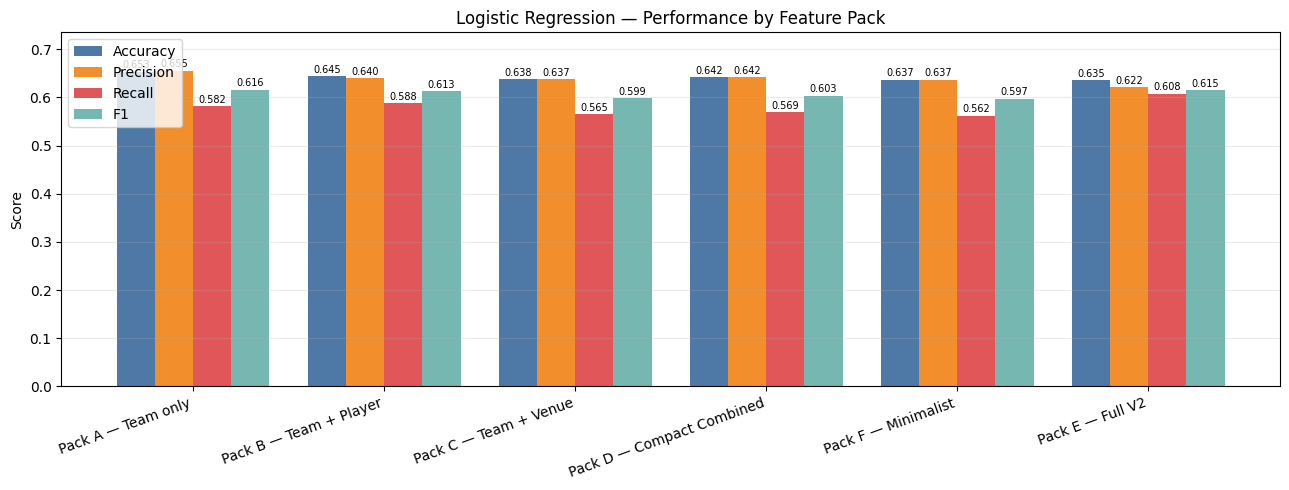

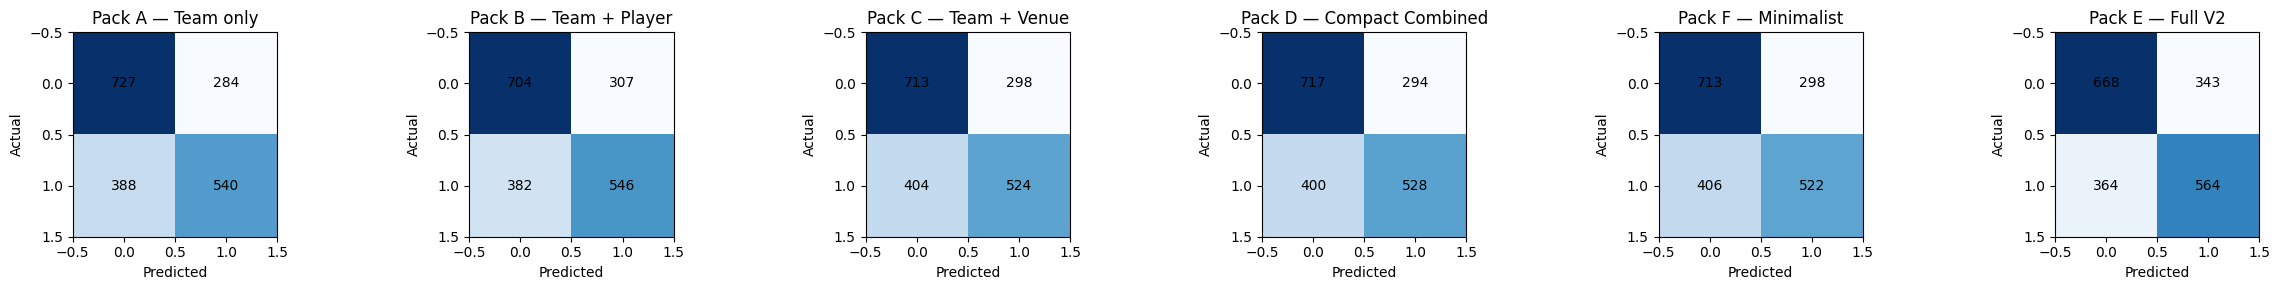

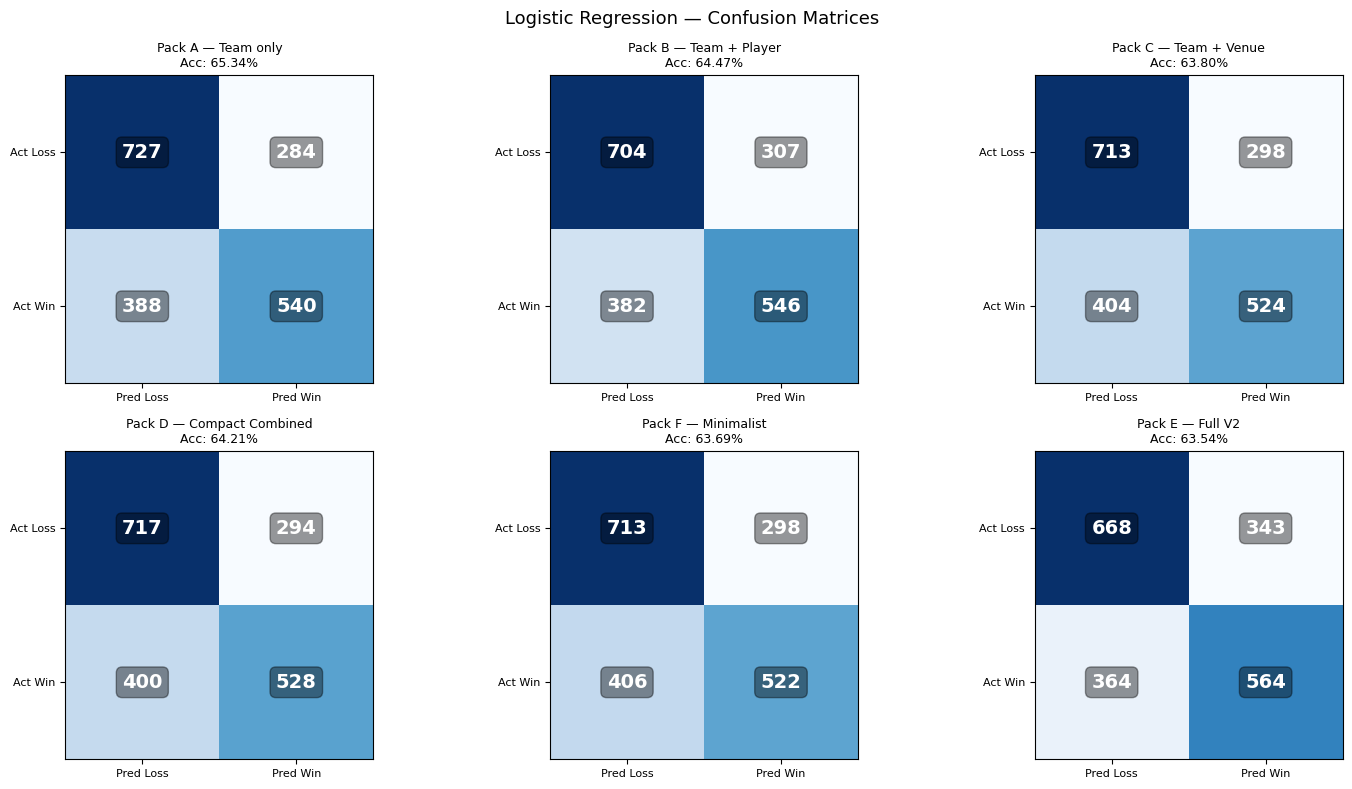

In [6]:
plot_pack_results(logreg_results, 'Logistic Regression')
plot_confusion_matrices(logreg_results, 'Logistic Regression')

---
## Section 2 — Linear Discriminant Analysis (LDA)

In [7]:
print('Training LDA on all packs...')
lda_results = {}

for pack_name, feature_cols in PACKS.items():
    X_train, X_test, y_train, y_test = time_based_split(df, feature_cols)
    model = LDAModel()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    lda_results[pack_name] = get_metrics(y_test, preds)
    print(f'  {pack_name}: Accuracy = {lda_results[pack_name]["accuracy"]:.4f}')

print('\nDone.')

Training LDA on all packs...
[LDA] Training done.
  Pack A — Team only: Accuracy = 0.6524
[LDA] Training done.
  Pack B — Team + Player: Accuracy = 0.6503
[LDA] Training done.
  Pack C — Team + Venue: Accuracy = 0.6509
[LDA] Training done.
  Pack D — Compact Combined: Accuracy = 0.6411
[LDA] Training done.
  Pack F — Minimalist: Accuracy = 0.6374
[LDA] Training done.
  Pack E — Full V2: Accuracy = 0.6349

Done.


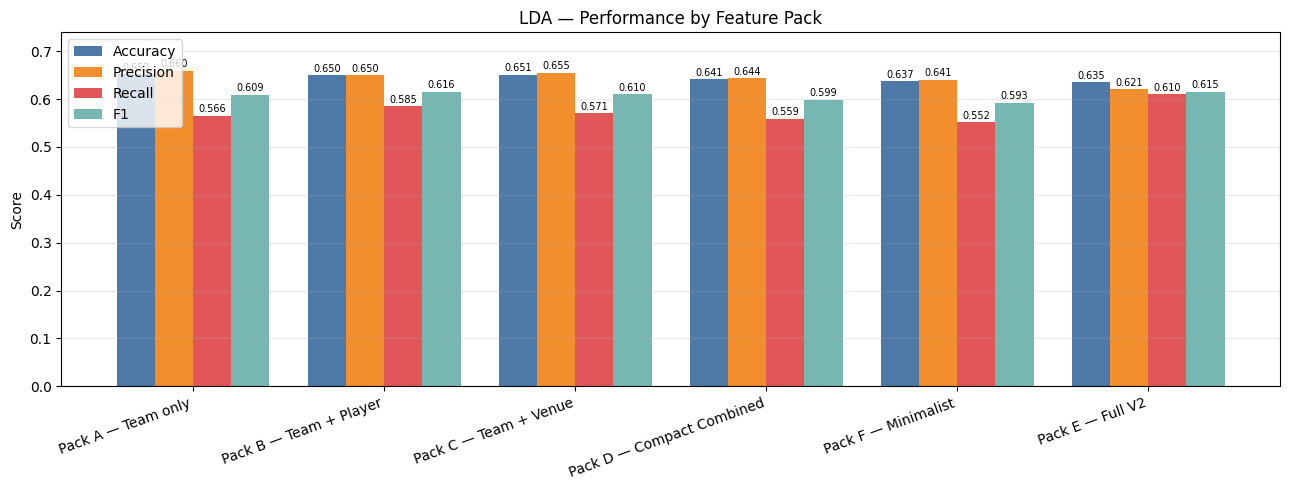

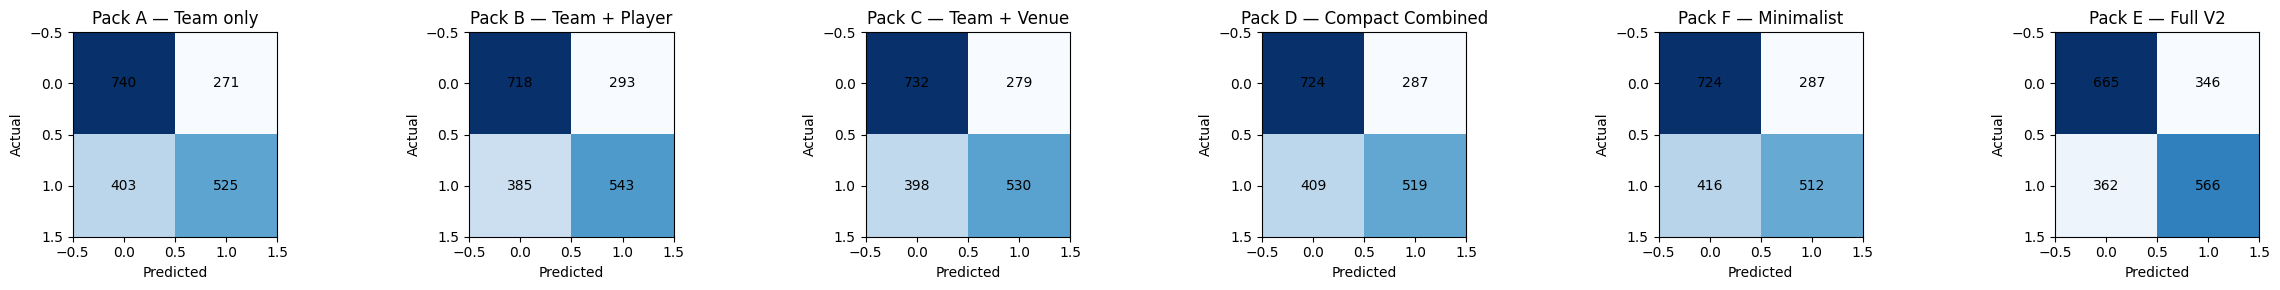

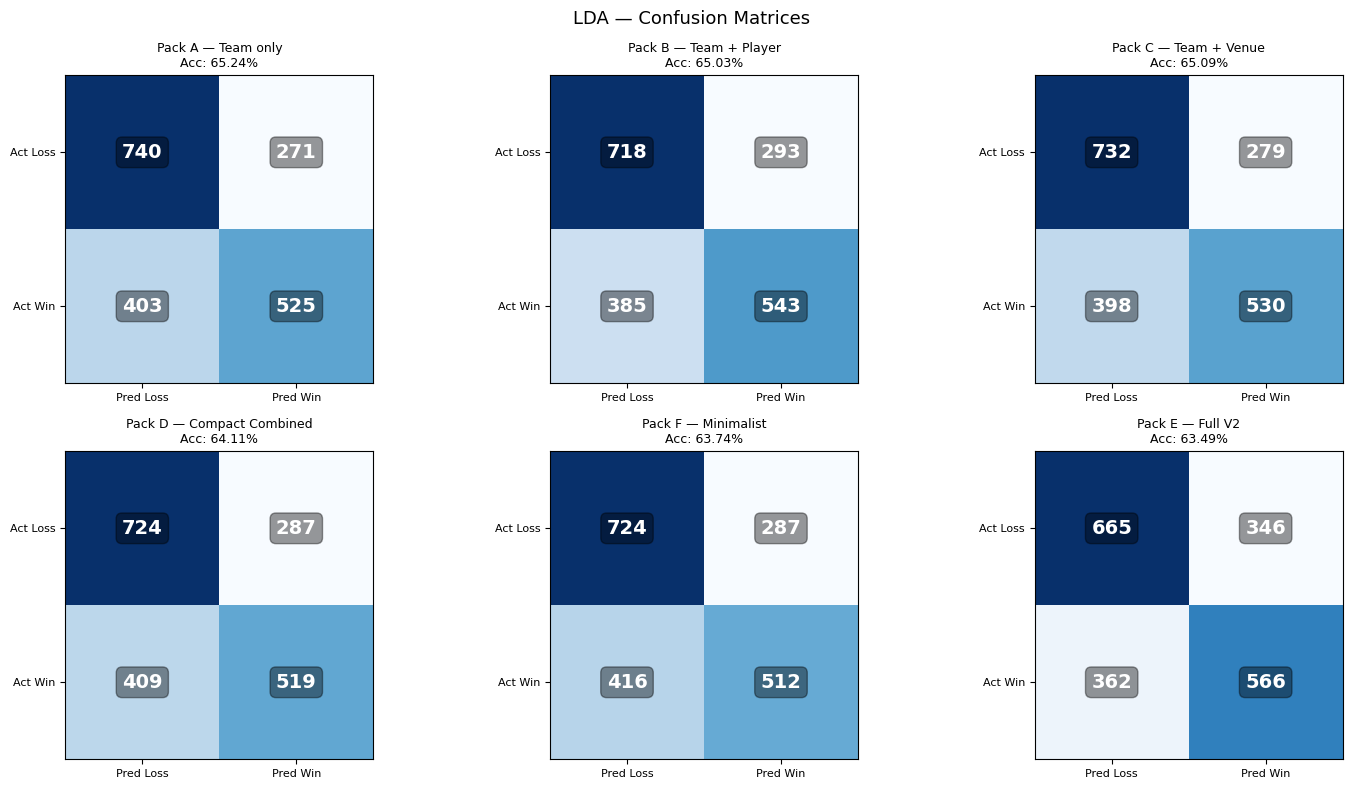

In [8]:
plot_pack_results(lda_results, 'LDA')
plot_confusion_matrices(lda_results, 'LDA')

---
## Section 3 — Support Vector Machine Linear


In [9]:
print('Training Linear SVM on all packs...')
svm_linear_results = {}

for pack_name, feature_cols in PACKS.items():
    print(f'  Training on {pack_name} ({len(feature_cols)} features)...')
    X_train, X_test, y_train, y_test = time_based_split(df, feature_cols)
    model = SVMLinearModel()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    svm_linear_results[pack_name] = get_metrics(y_test, preds)
    print(f'  {pack_name}: Accuracy = {svm_linear_results[pack_name]["accuracy"]:.4f}')

print('\nDone.')

Training Linear SVM on all packs...
  Training on Pack A — Team only (15 features)...
[SVM Linear] Training done.
  Pack A — Team only: Accuracy = 0.6519
  Training on Pack B — Team + Player (39 features)...
[SVM Linear] Training done.
  Pack B — Team + Player: Accuracy = 0.6426
  Training on Pack C — Team + Venue (31 features)...
[SVM Linear] Training done.
  Pack C — Team + Venue: Accuracy = 0.6447
  Training on Pack D — Compact Combined (28 features)...
[SVM Linear] Training done.
  Pack D — Compact Combined: Accuracy = 0.6318
  Training on Pack F — Minimalist (15 features)...
[SVM Linear] Training done.
  Pack F — Minimalist: Accuracy = 0.6431
  Training on Pack E — Full V2 (265 features)...
[SVM Linear] Training done.
  Pack E — Full V2: Accuracy = 0.6307

Done.


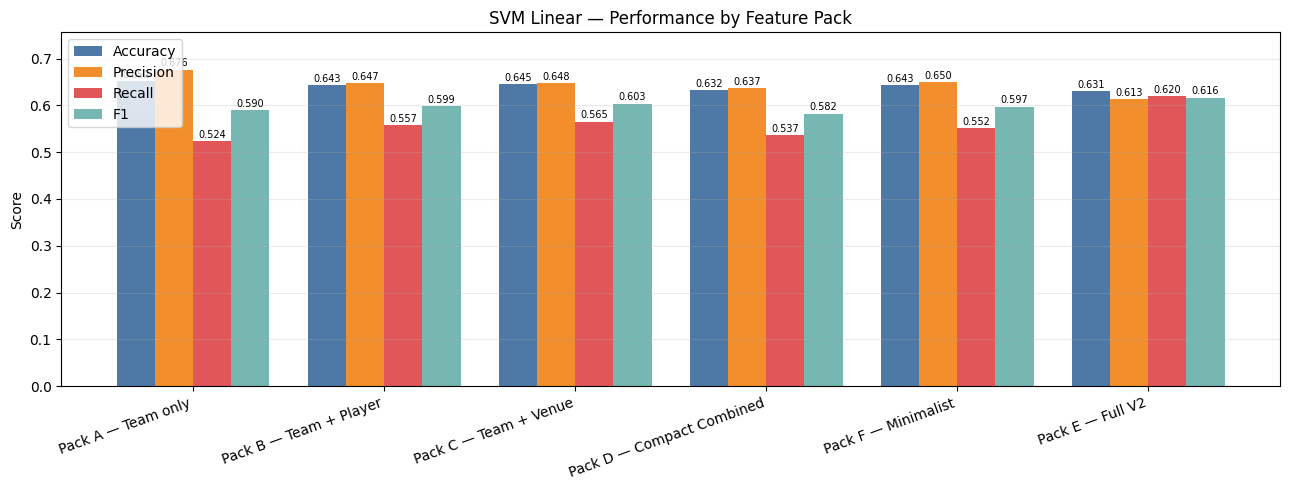

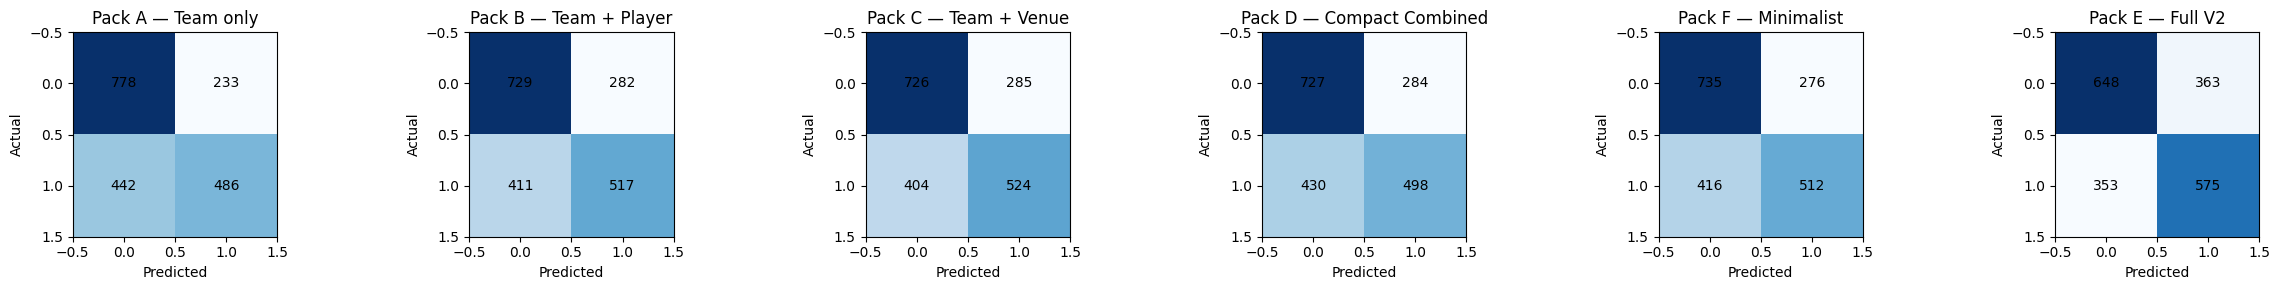

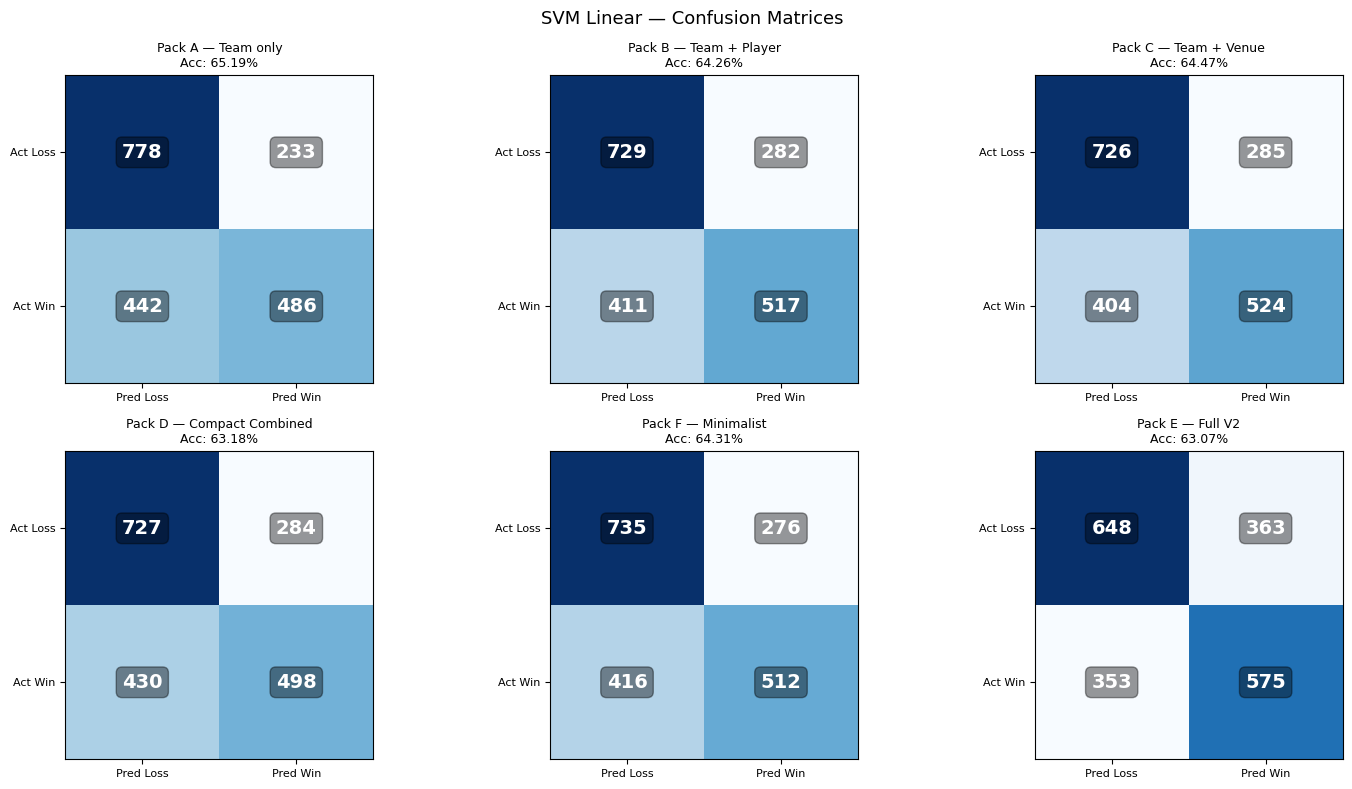

In [10]:
plot_pack_results(svm_linear_results, 'SVM Linear')
plot_confusion_matrices(svm_linear_results, 'SVM Linear')

---
## Section 4 — Final Comparison: LogReg vs LDA vs SVM Linear

In [11]:
rows = []
for pack_name in PACKS.keys():
    rows.append({
        'Pack':       pack_name,
        'LogReg':     f"{logreg_results[pack_name]['accuracy']:.4f}",
        'LDA':        f"{lda_results[pack_name]['accuracy']:.4f}",
        'SVM Linear': f"{svm_linear_results[pack_name]['accuracy']:.4f}",
    })

comparison_df = pd.DataFrame(rows).set_index('Pack')
print('=== Final Accuracy Comparison — LogReg vs LDA vs SVM Linear ===')
display(comparison_df)

=== Final Accuracy Comparison — LogReg vs LDA vs SVM Linear ===


,LogReg,LDA,SVM Linear
Pack,,,
Pack A — Team only,0.6534,0.6524,0.6519
Pack B — Team + Player,0.6447,0.6503,0.6426
Pack C — Team + Venue,0.6380,0.6509,0.6447
Pack D — Compact Combined,0.6421,0.6411,0.6318
Pack F — Minimalist,0.6369,0.6374,0.6431
Pack E — Full V2,0.6354,0.6349,0.6307


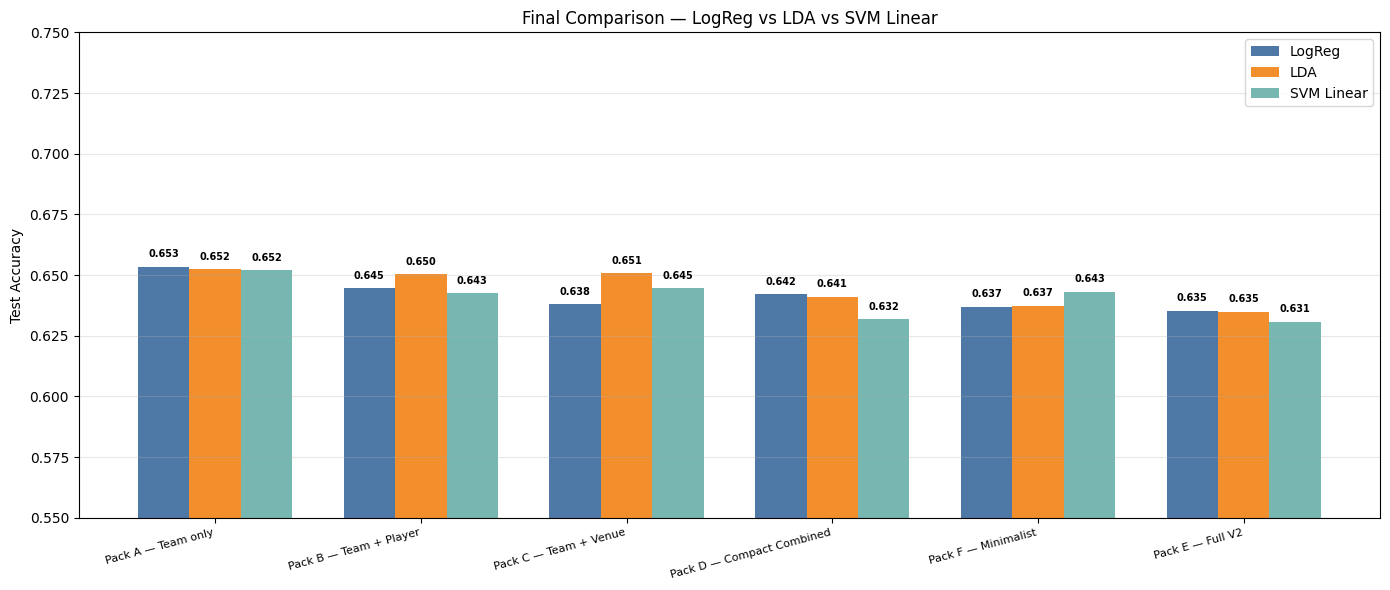

In [12]:
pack_names  = list(PACKS.keys())
model_names = ['LogReg', 'LDA', 'SVM Linear']
colors      = ['#4e79a7', '#f28e2b', '#76b7b2']
all_results = [logreg_results, lda_results, svm_linear_results]

x     = np.arange(len(pack_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model_name, color, results) in enumerate(zip(model_names, colors, all_results)):
    accuracies = [results[p]['accuracy'] for p in pack_names]
    bars = ax.bar(x + i*width, accuracies, width, label=model_name, color=color)
    for bar, acc in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{acc:.3f}',
                ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(pack_names, fontsize=8, rotation=15, ha='right')
ax.set_ylim(0.55, 0.75)
ax.set_ylabel('Test Accuracy')
ax.set_title('Final Comparison — LogReg vs LDA vs SVM Linear')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Section 5 — Support Vector Machine Non-Linear (RBF)


In [13]:
print('Training SVM on all packs...')
svm_results = {}

for pack_name, feature_cols in PACKS.items():
    print(f'  Training on {pack_name} ({len(feature_cols)} features)...')
    X_train, X_test, y_train, y_test = time_based_split(df, feature_cols)
    model = SVMModel()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    svm_results[pack_name] = get_metrics(y_test, preds)
    print(f'  {pack_name}: Accuracy = {svm_results[pack_name]["accuracy"]:.4f}')

print('\nDone.')

Training SVM on all packs...
  Training on Pack A — Team only (15 features)...
[SVM RBF] Training done.
  Pack A — Team only: Accuracy = 0.6447
  Training on Pack B — Team + Player (39 features)...
[SVM RBF] Training done.
  Pack B — Team + Player: Accuracy = 0.6354
  Training on Pack C — Team + Venue (31 features)...
[SVM RBF] Training done.
  Pack C — Team + Venue: Accuracy = 0.6509
  Training on Pack D — Compact Combined (28 features)...
[SVM RBF] Training done.
  Pack D — Compact Combined: Accuracy = 0.6380
  Training on Pack F — Minimalist (15 features)...
[SVM RBF] Training done.
  Pack F — Minimalist: Accuracy = 0.6271
  Training on Pack E — Full V2 (265 features)...
[SVM RBF] Training done.
  Pack E — Full V2: Accuracy = 0.6338

Done.


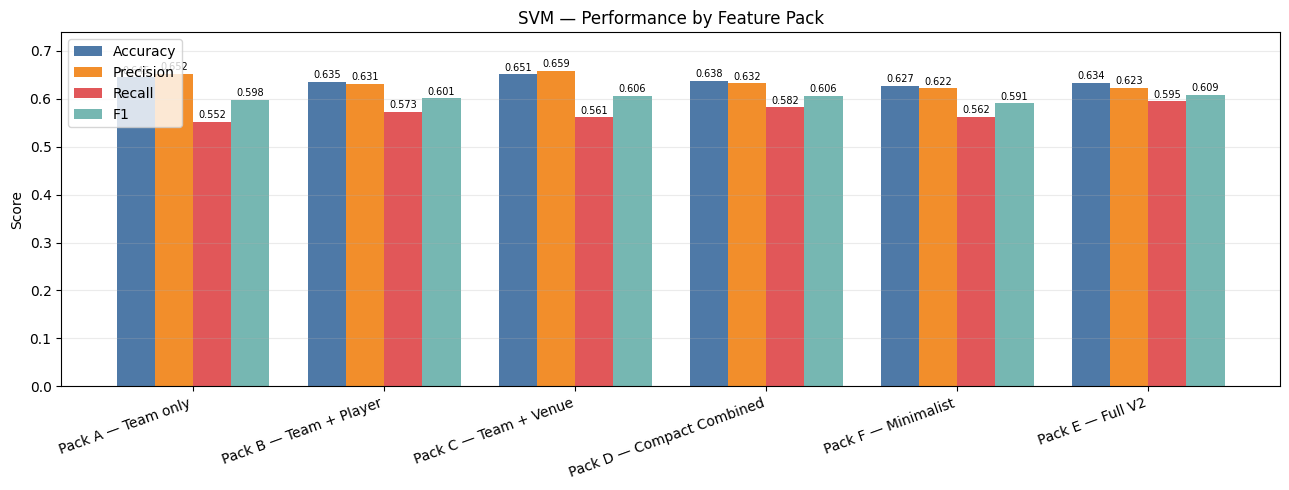

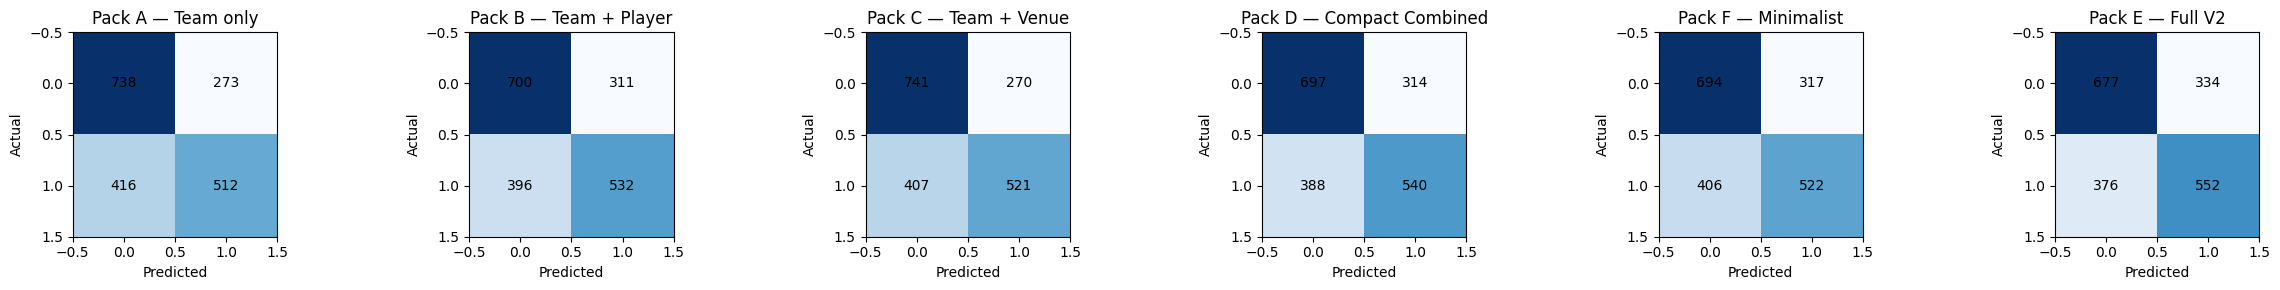

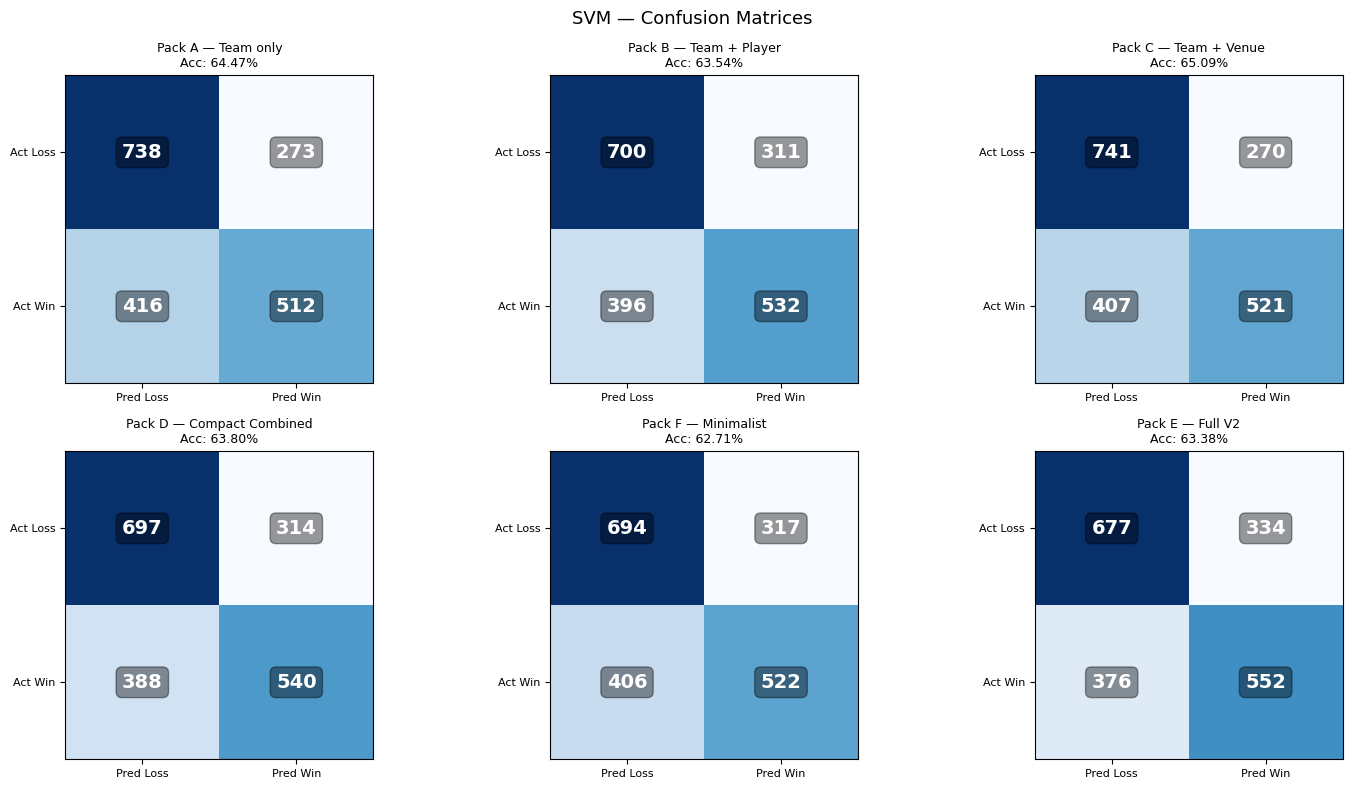

In [14]:
plot_pack_results(svm_results, 'SVM')
plot_confusion_matrices(svm_results, 'SVM')

## Section 6 — Coeffecient based top-K pruning

In [16]:
print('Training all 3 models on 265 features...')

PACK_E = [c for c in df.columns if c not in EXCLUDE_COLS]
X_train, X_test, y_train, y_test = time_based_split(df, PACK_E)

logreg_w = LogisticRegressionModel()
logreg_w.fit(X_train, y_train)

lda_w = LDAModel()
lda_w.fit(X_train, y_train)

print('[Linear SVM] This will take several minutes...')
svm_lin_w = SVMLinearModel()
svm_lin_w.fit(X_train, y_train)

print('\n--- Results on 265 features ---')
r265 = {
    'LogReg':     get_metrics(y_test, logreg_w.predict(X_test)),
    'LDA':        get_metrics(y_test, lda_w.predict(X_test)),
    'SVM Linear': get_metrics(y_test, svm_lin_w.predict(X_test)),
}
for name, r in r265.items():
    print(f'  {name}: Accuracy = {r["accuracy"]:.4f}')

# Get weights
logreg_weights = pd.DataFrame({
    'Feature':     PACK_E,
    'Coefficient': logreg_w.model.coef_[0],
    'Abs':         abs(logreg_w.model.coef_[0])
}).sort_values('Abs', ascending=False).reset_index(drop=True)

lda_weights = pd.DataFrame({
    'Feature':     PACK_E,
    'Coefficient': lda_w.model.coef_[0],
    'Abs':         abs(lda_w.model.coef_[0])
}).sort_values('Abs', ascending=False).reset_index(drop=True)

svm_weights = pd.DataFrame({
    'Feature':     PACK_E,
    'Coefficient': svm_lin_w.model.coef_[0],
    'Abs':         abs(svm_lin_w.model.coef_[0])
}).sort_values('Abs', ascending=False).reset_index(drop=True)

print('\nWeights extracted from all 3 models.')

Training all 3 models on 265 features...
[LDA] Training done.
[Linear SVM] This will take several minutes...
[SVM Linear] Training done.

--- Results on 265 features ---
  LogReg: Accuracy = 0.6354
  LDA: Accuracy = 0.6349
  SVM Linear: Accuracy = 0.6307

Weights extracted from all 3 models.


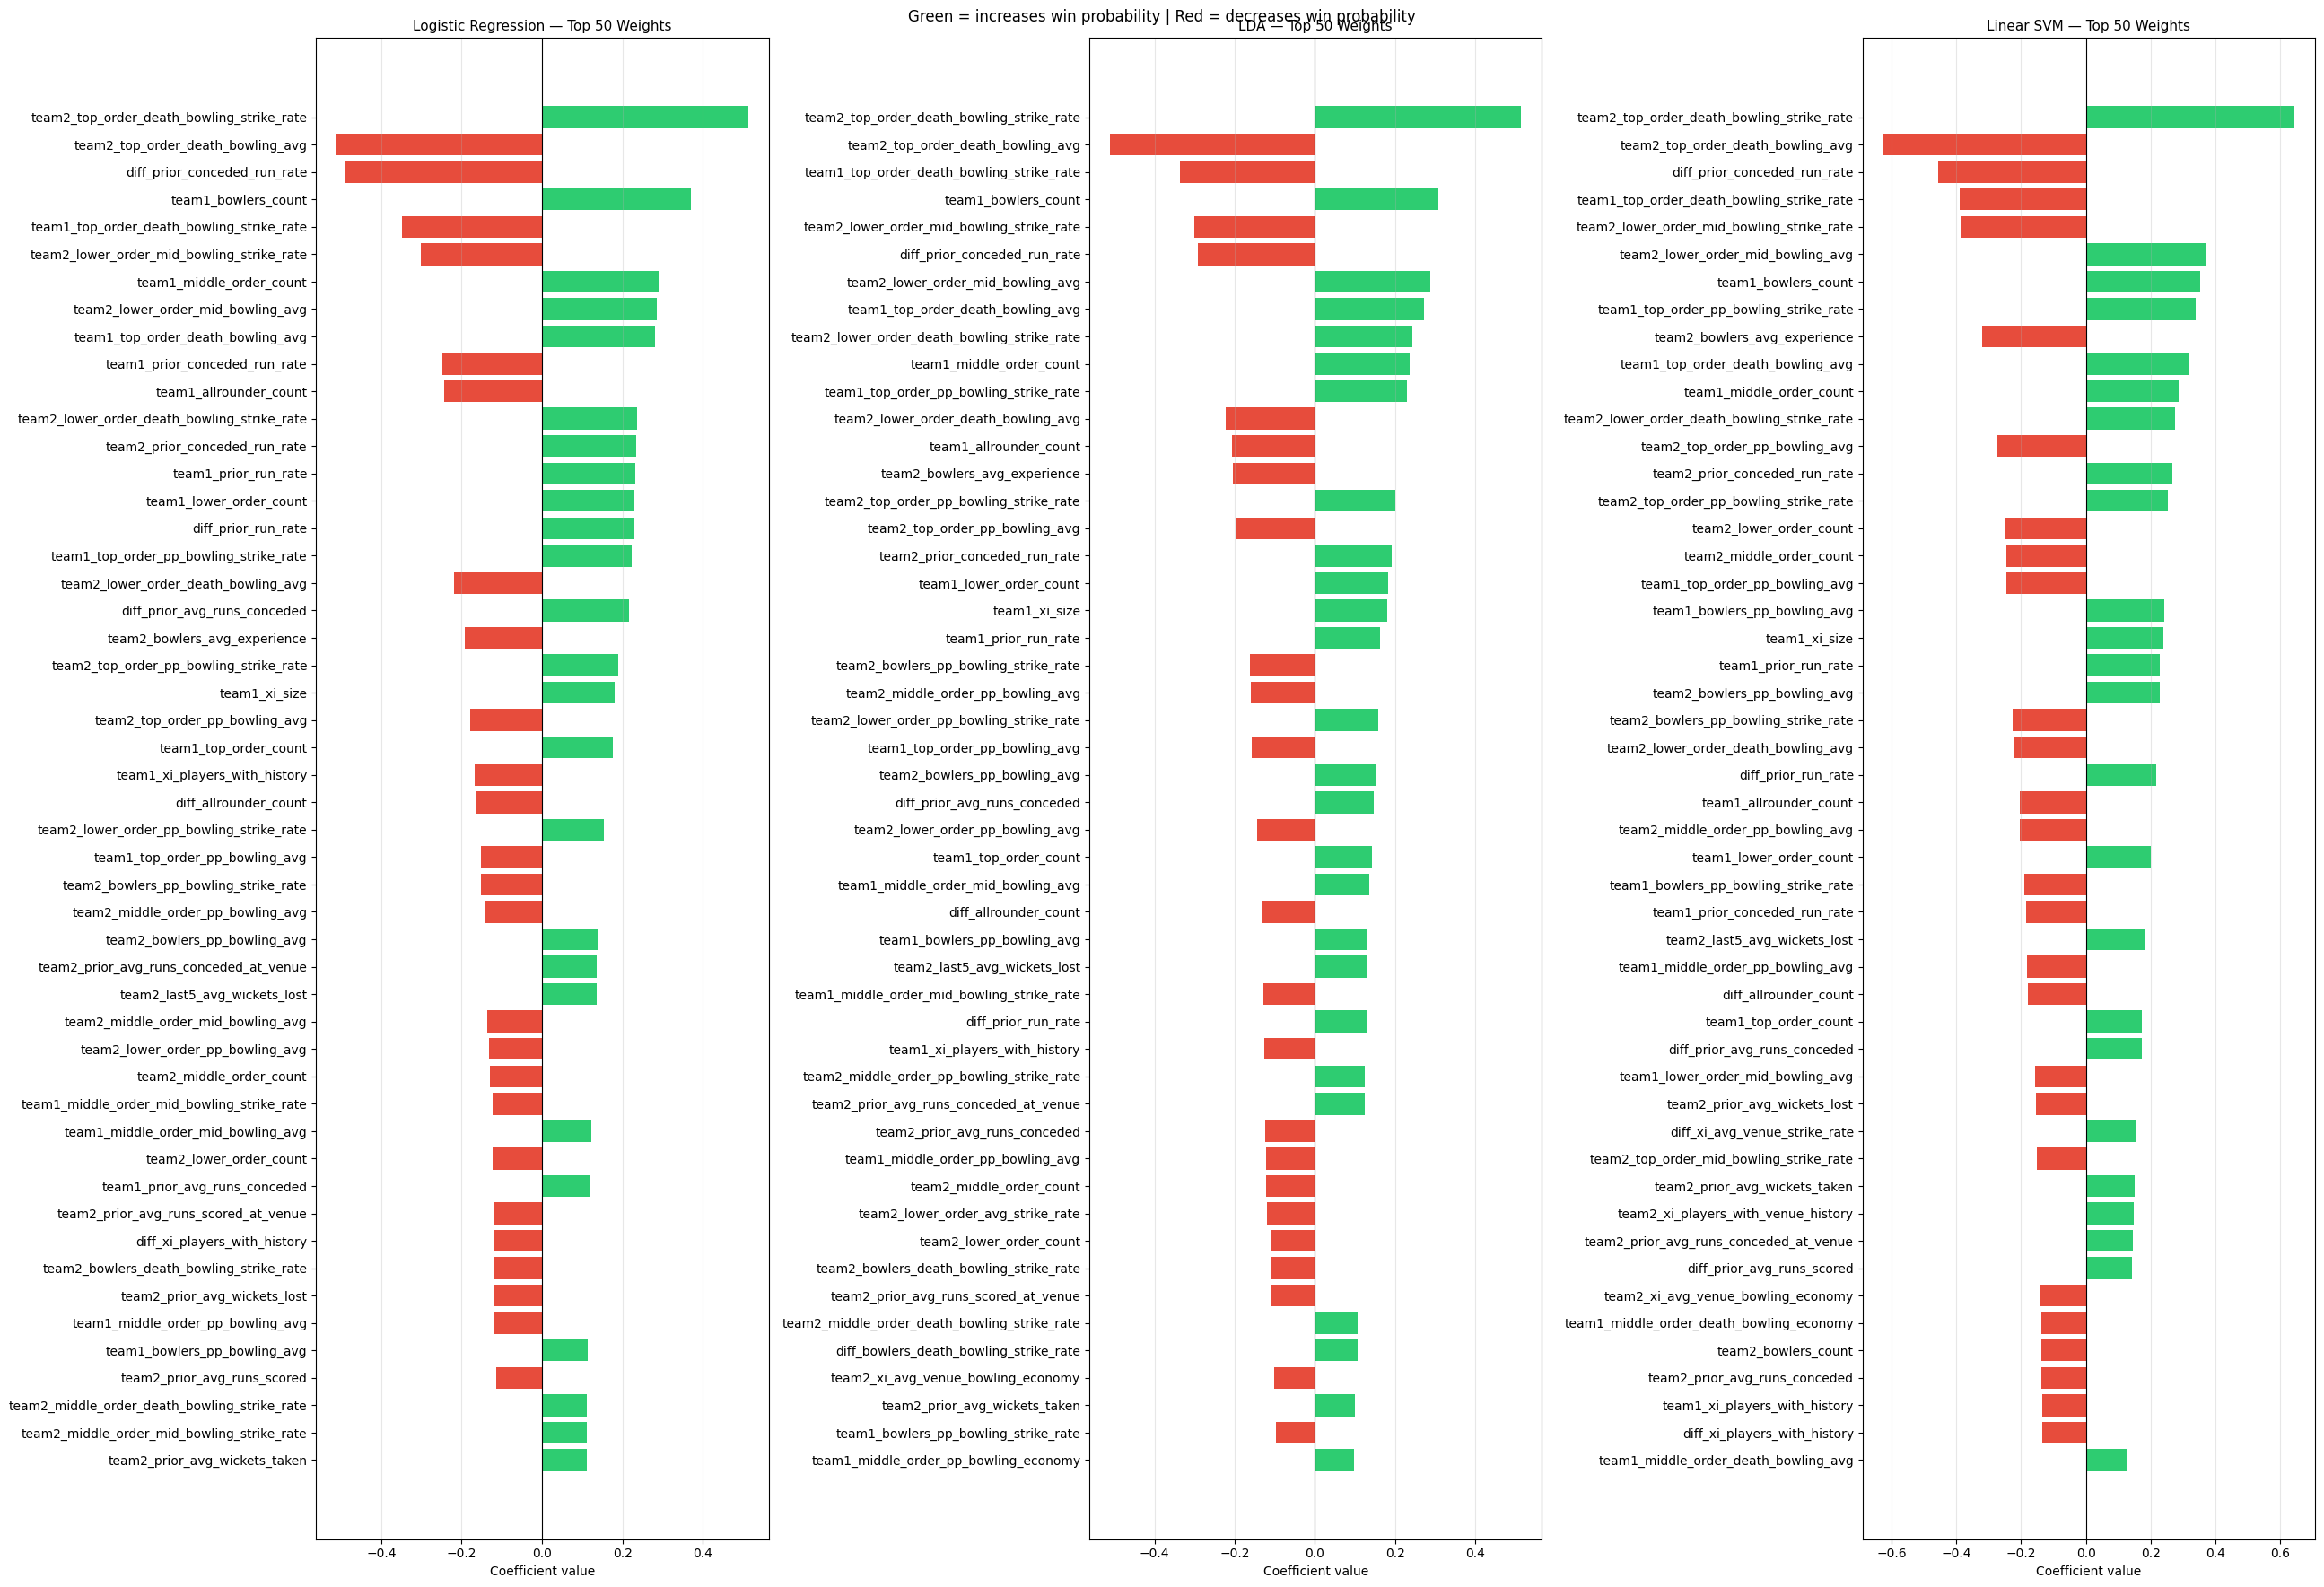

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(26, 18))

for ax, weights_df, title in zip(
    axes,
    [logreg_weights, lda_weights, svm_weights],
    ['Logistic Regression', 'LDA', 'Linear SVM'],
):
    top50 = weights_df.head(50)
    colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in top50['Coefficient'][::-1]]
    ax.barh(top50['Feature'][::-1], top50['Coefficient'][::-1], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{title} — Top 50 Weights', fontsize=11)
    ax.set_xlabel('Coefficient value')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Green = increases win probability | Red = decreases win probability', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
print('===== Retraining on Top 50 Features =====')

top50_logreg = logreg_weights['Feature'].head(50).tolist()
top50_lda    = lda_weights['Feature'].head(50).tolist()
top50_svm    = svm_weights['Feature'].head(50).tolist()

r50 = {}

for selection_name, feature_cols in [
    ('Top 50 — LogReg selected',     top50_logreg),
    ('Top 50 — LDA selected',        top50_lda),
    ('Top 50 — SVM Linear selected', top50_svm),
]:
    print(f'\n--- {selection_name} ---')
    X_train_s, X_test_s, y_train_s, y_test_s = time_based_split(df, feature_cols)

    m_logreg = LogisticRegressionModel()
    m_logreg.fit(X_train_s, y_train_s)

    m_lda = LDAModel()
    m_lda.fit(X_train_s, y_train_s)

    m_svm_lin = SVMLinearModel()
    m_svm_lin.fit(X_train_s, y_train_s)

    r50[selection_name] = {
        'LogReg':     get_metrics(y_test_s, m_logreg.predict(X_test_s)),
        'LDA':        get_metrics(y_test_s, m_lda.predict(X_test_s)),
        'SVM Linear': get_metrics(y_test_s, m_svm_lin.predict(X_test_s)),
    }

    for model_name, r in r50[selection_name].items():
        print(f'  {model_name}: Accuracy = {r["accuracy"]:.4f}')

print('\nDone.')

===== Retraining on Top 50 Features =====

--- Top 50 — LogReg selected ---
[LDA] Training done.
[SVM Linear] Training done.
  LogReg: Accuracy = 0.6276
  LDA: Accuracy = 0.6261
  SVM Linear: Accuracy = 0.6178

--- Top 50 — LDA selected ---
[LDA] Training done.
[SVM Linear] Training done.
  LogReg: Accuracy = 0.6158
  LDA: Accuracy = 0.6158
  SVM Linear: Accuracy = 0.6173

--- Top 50 — SVM Linear selected ---
[LDA] Training done.
[SVM Linear] Training done.
  LogReg: Accuracy = 0.6235
  LDA: Accuracy = 0.6158
  SVM Linear: Accuracy = 0.6163

Done.


In [19]:
print('===== Retraining on Top 25 Features =====')

top25_logreg = logreg_weights['Feature'].head(25).tolist()
top25_lda    = lda_weights['Feature'].head(25).tolist()
top25_svm    = svm_weights['Feature'].head(25).tolist()

r25 = {}

for selection_name, feature_cols in [
    ('Top 25 — LogReg selected',     top25_logreg),
    ('Top 25 — LDA selected',        top25_lda),
    ('Top 25 — SVM Linear selected', top25_svm),
]:
    print(f'\n--- {selection_name} ---')
    X_train_s, X_test_s, y_train_s, y_test_s = time_based_split(df, feature_cols)

    m_logreg = LogisticRegressionModel()
    m_logreg.fit(X_train_s, y_train_s)

    m_lda = LDAModel()
    m_lda.fit(X_train_s, y_train_s)

    m_svm_lin = SVMLinearModel()
    m_svm_lin.fit(X_train_s, y_train_s)

    r25[selection_name] = {
        'LogReg':     get_metrics(y_test_s, m_logreg.predict(X_test_s)),
        'LDA':        get_metrics(y_test_s, m_lda.predict(X_test_s)),
        'SVM Linear': get_metrics(y_test_s, m_svm_lin.predict(X_test_s)),
    }

    for model_name, r in r25[selection_name].items():
        print(f'  {model_name}: Accuracy = {r["accuracy"]:.4f}')

print('\nDone.')

===== Retraining on Top 25 Features =====

--- Top 25 — LogReg selected ---
[LDA] Training done.
[SVM Linear] Training done.
  LogReg: Accuracy = 0.6215
  LDA: Accuracy = 0.6153
  SVM Linear: Accuracy = 0.6220

--- Top 25 — LDA selected ---
[LDA] Training done.
[SVM Linear] Training done.
  LogReg: Accuracy = 0.5817
  LDA: Accuracy = 0.5848
  SVM Linear: Accuracy = 0.5895

--- Top 25 — SVM Linear selected ---
[LDA] Training done.
[SVM Linear] Training done.
  LogReg: Accuracy = 0.6147
  LDA: Accuracy = 0.6209
  SVM Linear: Accuracy = 0.6163

Done.


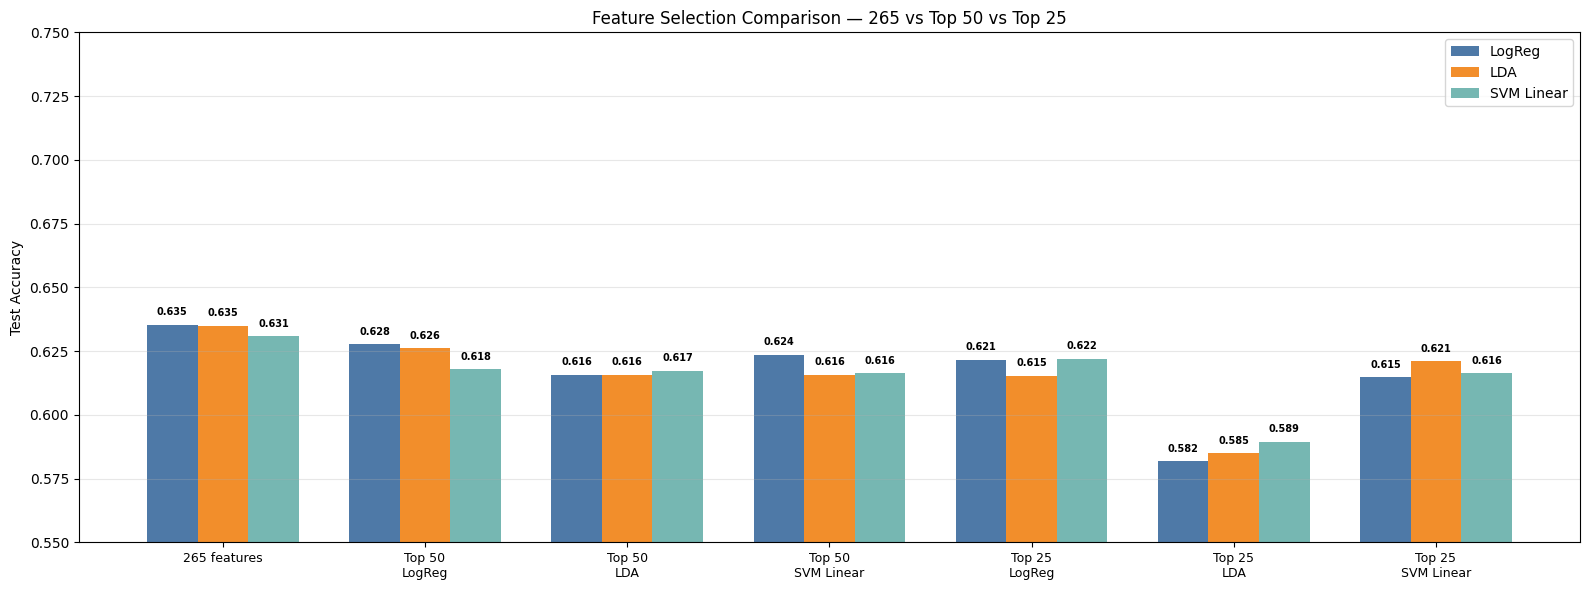

In [20]:
fig, ax = plt.subplots(figsize=(16, 6))

experiment_names = [
    '265 features',
    'Top 50\nLogReg',
    'Top 50\nLDA',
    'Top 50\nSVM Linear',
    'Top 25\nLogReg',
    'Top 25\nLDA',
    'Top 25\nSVM Linear',
]

model_names = ['LogReg', 'LDA', 'SVM Linear']
colors      = ['#4e79a7', '#f28e2b', '#76b7b2']

x     = np.arange(len(experiment_names))
width = 0.25

for i, (model_name, color) in enumerate(zip(model_names, colors)):
    accuracies = [
        r265[model_name]['accuracy'],
        r50['Top 50 — LogReg selected'][model_name]['accuracy'],
        r50['Top 50 — LDA selected'][model_name]['accuracy'],
        r50['Top 50 — SVM Linear selected'][model_name]['accuracy'],
        r25['Top 25 — LogReg selected'][model_name]['accuracy'],
        r25['Top 25 — LDA selected'][model_name]['accuracy'],
        r25['Top 25 — SVM Linear selected'][model_name]['accuracy'],
    ]

    bars = ax.bar(x + i*width, accuracies, width, label=model_name, color=color)
    for bar, acc in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{acc:.3f}',
                ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(experiment_names, fontsize=9)
ax.set_ylim(0.55, 0.75)
ax.set_ylabel('Test Accuracy')
ax.set_title('Feature Selection Comparison — 265 vs Top 50 vs Top 25')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 7 — Hyperparameter Tuning (Model Optimization)
### Using Grid Search to find the best parameters for each model on Pack E

In [22]:
print("===== Hyperparameter Tuning on Pack E (Full Features) =====")
print("Selection is based on VALIDATION accuracy. Test is used only once at the end.")
print()

X_train, X_val, X_test, y_train, y_val, y_test = time_based_train_val_test_split(df, PACK_E)

# ── Logistic Regression ──────────────────────────────────────
print("--- Tuning Logistic Regression ---")
best_val_acc = -1
best_C = None
best_logreg = None

for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    model = LogisticRegressionModel(C=C)
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    print(f"  C={C:<8} Validation Accuracy = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_C = C
        best_logreg = model

logreg_packe_val_acc = best_val_acc
logreg_packe_test_acc = accuracy_score(y_test, best_logreg.predict(X_test))
print(f"\n  Best C: {best_C}  Validation Accuracy: {logreg_packe_val_acc:.4f}  Test Accuracy: {logreg_packe_test_acc:.4f}")


# ── LDA ──────────────────────────────────────────────────────
print()
print("--- Tuning LDA ---")
best_val_acc = -1
best_solver = None
best_shrinkage = None
best_lda = None

lda_configs = [
    {"solver": "svd", "shrinkage": None},
    {"solver": "lsqr", "shrinkage": "auto"},
    {"solver": "lsqr", "shrinkage": 0.1},
    {"solver": "lsqr", "shrinkage": 0.3},
    {"solver": "lsqr", "shrinkage": 0.5},
    {"solver": "lsqr", "shrinkage": 0.7},
    {"solver": "lsqr", "shrinkage": 0.9},
]

for cfg in lda_configs:
    model = LDAModel(solver=cfg["solver"], shrinkage=cfg["shrinkage"])
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    print(f"  solver={cfg['solver']:<4} shrinkage={str(cfg['shrinkage']):<6} Validation Accuracy = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_solver = cfg["solver"]
        best_shrinkage = cfg["shrinkage"]
        best_lda = model

lda_packe_val_acc = best_val_acc
lda_packe_test_acc = accuracy_score(y_test, best_lda.predict(X_test))
print(f"\n  Best solver: {best_solver}  Best shrinkage: {best_shrinkage}  Validation Accuracy: {lda_packe_val_acc:.4f}  Test Accuracy: {lda_packe_test_acc:.4f}")


# ── Linear SVM ───────────────────────────────────────────────
print()
print("--- Tuning Linear SVM ---")
best_val_acc = -1
best_C = None
best_svm = None

for C in [0.01, 0.1, 1.0, 10.0]:
    model = SVMLinearModel(C=C)
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    print(f"  C={C:<8} Validation Accuracy = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_C = C
        best_svm = model

svm_packe_val_acc = best_val_acc
svm_packe_test_acc = accuracy_score(y_test, best_svm.predict(X_test))
print(f"\n  Best C: {best_C}  Validation Accuracy: {svm_packe_val_acc:.4f}  Test Accuracy: {svm_packe_test_acc:.4f}")

===== Hyperparameter Tuning on Pack E (Full Features) =====
Selection is based on VALIDATION accuracy. Test is used only once at the end.

--- Tuning Logistic Regression ---
  C=0.01     Validation Accuracy = 0.6140
  C=0.1      Validation Accuracy = 0.6202
  C=1.0      Validation Accuracy = 0.6120
  C=10.0     Validation Accuracy = 0.6089
  C=100.0    Validation Accuracy = 0.6078

  Best C: 0.1  Validation Accuracy: 0.6202  Test Accuracy: 0.6359

--- Tuning LDA ---
[LDA] Training done.
  solver=svd  shrinkage=None   Validation Accuracy = 0.6130
[LDA] Training done.
  solver=lsqr shrinkage=auto   Validation Accuracy = 0.6213
[LDA] Training done.
  solver=lsqr shrinkage=0.1    Validation Accuracy = 0.6130
[LDA] Training done.
  solver=lsqr shrinkage=0.3    Validation Accuracy = 0.6336
[LDA] Training done.
  solver=lsqr shrinkage=0.5    Validation Accuracy = 0.6347
[LDA] Training done.
  solver=lsqr shrinkage=0.7    Validation Accuracy = 0.6316
[LDA] Training done.
  solver=lsqr shrinkag

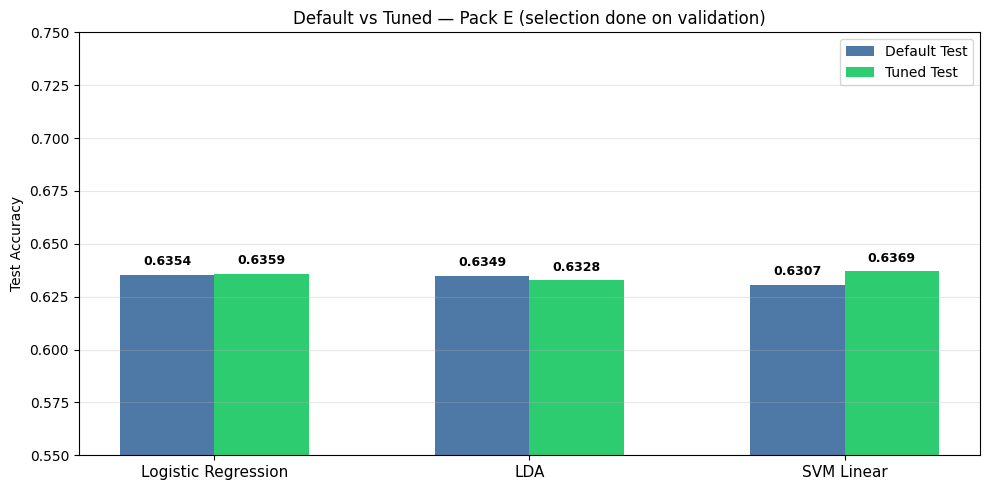

Validation-selected results on Pack E:
  Logistic Regression: val=0.6202, test=0.6359, default test=0.6354
  LDA:                 val=0.6378, test=0.6328, default test=0.6349
  SVM Linear:          val=0.6213, test=0.6369, default test=0.6307


In [23]:

# Default test accuracies from Pack E (from the earlier fixed train/test comparison)
default_logreg = logreg_results['Pack E — Full V2']['accuracy']
default_lda    = lda_results['Pack E — Full V2']['accuracy']
default_svm    = svm_linear_results['Pack E — Full V2']['accuracy']

fig, ax = plt.subplots(figsize=(10, 5))

models   = ['Logistic Regression', 'LDA', 'SVM Linear']
defaults = [default_logreg, default_lda, default_svm]
tuned    = [logreg_packe_test_acc, lda_packe_test_acc, svm_packe_test_acc]

x     = np.arange(len(models))
width = 0.3

bars1 = ax.bar(x - width/2, defaults, width, label='Default Test', color='#4e79a7')
bars2 = ax.bar(x + width/2, tuned,    width, label='Tuned Test',   color='#2ecc71')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0.55, 0.75)
ax.set_ylabel('Test Accuracy')
ax.set_title('Default vs Tuned — Pack E (selection done on validation)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Validation-selected results on Pack E:')
print(f'  Logistic Regression: val={logreg_packe_val_acc:.4f}, test={logreg_packe_test_acc:.4f}, default test={default_logreg:.4f}')
print(f'  LDA:                 val={lda_packe_val_acc:.4f}, test={lda_packe_test_acc:.4f}, default test={default_lda:.4f}')
print(f'  SVM Linear:          val={svm_packe_val_acc:.4f}, test={svm_packe_test_acc:.4f}, default test={default_svm:.4f}')


---
### Using Grid Search to find the best parameters for each model on Pack A (Team Only)

===== Hyperparameter Tuning on Pack A (Team Only) =====
Selection is based on VALIDATION accuracy. Test is used only once at the end.

--- Tuning Logistic Regression ---
  C=0.01     Validation Accuracy = 0.6285
  C=0.1      Validation Accuracy = 0.6202
  C=1.0      Validation Accuracy = 0.6202
  C=10.0     Validation Accuracy = 0.6192
  C=100.0    Validation Accuracy = 0.6192

  Best C: 0.01  Validation Accuracy: 0.6285  Test Accuracy: 0.6529

--- Tuning LDA ---
[LDA] Training done.
  solver=svd  shrinkage=None   Validation Accuracy = 0.6182
[LDA] Training done.
  solver=lsqr shrinkage=auto   Validation Accuracy = 0.6233
[LDA] Training done.
  solver=lsqr shrinkage=0.1    Validation Accuracy = 0.6285
[LDA] Training done.
  solver=lsqr shrinkage=0.3    Validation Accuracy = 0.6305
[LDA] Training done.
  solver=lsqr shrinkage=0.5    Validation Accuracy = 0.6285
[LDA] Training done.
  solver=lsqr shrinkage=0.7    Validation Accuracy = 0.6264
[LDA] Training done.
  solver=lsqr shrinkage=0

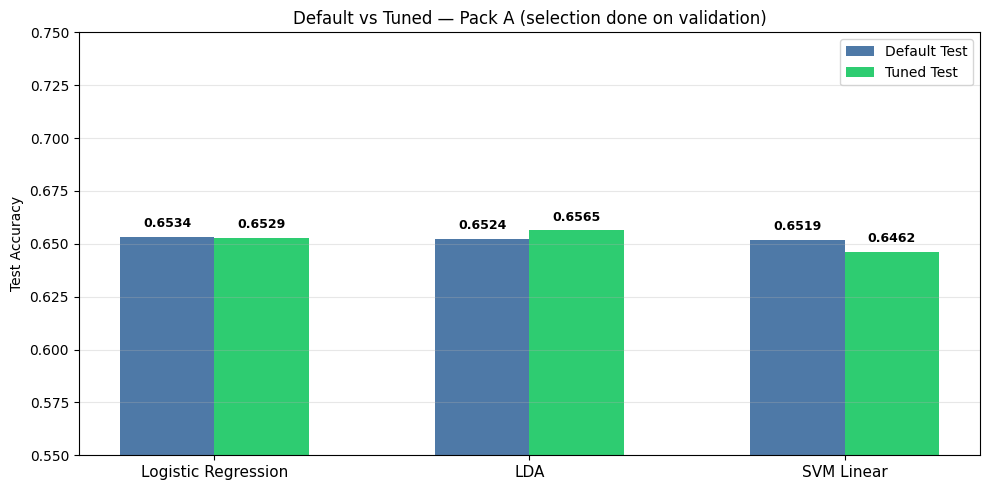

Validation-selected results on Pack A:
  Logistic Regression: val=0.6285, test=0.6529, default test=0.6534
  LDA:                 val=0.6305, test=0.6565, default test=0.6524
  SVM Linear:          val=0.6264, test=0.6462, default test=0.6519


In [25]:
print("===== Hyperparameter Tuning on Pack A (Team Only) =====")
print("Selection is based on VALIDATION accuracy. Test is used only once at the end.")
print()

X_train_a, X_val_a, X_test_a, y_train_a, y_val_a, y_test_a = time_based_train_val_test_split(df, PACK_A)

# ── Logistic Regression ──────────────────────────────────────
print("--- Tuning Logistic Regression ---")
best_val_acc = -1
best_C = None
best_logreg_a = None

for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    model = LogisticRegressionModel(C=C)
    model.fit(X_train_a, y_train_a)

    val_pred = model.predict(X_val_a)
    val_acc = accuracy_score(y_val_a, val_pred)
    print(f"  C={C:<8} Validation Accuracy = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_C = C
        best_logreg_a = model

logreg_best_val_a = best_val_acc
logreg_best_acc_a = accuracy_score(y_test_a, best_logreg_a.predict(X_test_a))
print(f"\n  Best C: {best_C}  Validation Accuracy: {logreg_best_val_a:.4f}  Test Accuracy: {logreg_best_acc_a:.4f}")


# ── LDA ──────────────────────────────────────────────────────
print()
print("--- Tuning LDA ---")
best_val_acc = -1
best_solver = None
best_shrinkage = None
best_lda_a = None

lda_configs = [
    {"solver": "svd",  "shrinkage": None},
    {"solver": "lsqr", "shrinkage": "auto"},
    {"solver": "lsqr", "shrinkage": 0.1},
    {"solver": "lsqr", "shrinkage": 0.3},
    {"solver": "lsqr", "shrinkage": 0.5},
    {"solver": "lsqr", "shrinkage": 0.7},
    {"solver": "lsqr", "shrinkage": 0.9},
]

for cfg in lda_configs:
    model = LDAModel(solver=cfg["solver"], shrinkage=cfg["shrinkage"])
    model.fit(X_train_a, y_train_a)

    val_pred = model.predict(X_val_a)
    val_acc = accuracy_score(y_val_a, val_pred)
    print(f"  solver={cfg['solver']:<4} shrinkage={str(cfg['shrinkage']):<6} Validation Accuracy = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_solver = cfg["solver"]
        best_shrinkage = cfg["shrinkage"]
        best_lda_a = model

lda_best_val_a = best_val_acc
lda_best_acc_a = accuracy_score(y_test_a, best_lda_a.predict(X_test_a))
print(f"\n  Best solver: {best_solver}  Best shrinkage: {best_shrinkage}  Validation Accuracy: {lda_best_val_a:.4f}  Test Accuracy: {lda_best_acc_a:.4f}")


# ── Linear SVM ───────────────────────────────────────────────
print()
print("--- Tuning Linear SVM ---")
best_val_acc = -1
best_C = None
best_svm_a = None

for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    model = SVMLinearModel(C=C)
    model.fit(X_train_a, y_train_a)

    val_pred = model.predict(X_val_a)
    val_acc = accuracy_score(y_val_a, val_pred)
    print(f"  C={C:<8} Validation Accuracy = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_C = C
        best_svm_a = model

svm_best_val_a = best_val_acc
svm_best_acc_a = accuracy_score(y_test_a, best_svm_a.predict(X_test_a))
print(f"\n  Best C: {best_C}  Validation Accuracy: {svm_best_val_a:.4f}  Test Accuracy: {svm_best_acc_a:.4f}")


# ── Comparison plot ───────────────────────────────────────────
default_logreg_a = logreg_results["Pack A — Team only"]["accuracy"]
default_lda_a    = lda_results["Pack A — Team only"]["accuracy"]
default_svm_a    = svm_linear_results["Pack A — Team only"]["accuracy"]

fig, ax = plt.subplots(figsize=(10, 5))

models   = ["Logistic Regression", "LDA", "SVM Linear"]
defaults = [default_logreg_a, default_lda_a, default_svm_a]
tuned    = [logreg_best_acc_a, lda_best_acc_a, svm_best_acc_a]

x = np.arange(len(models))
width = 0.3

bars1 = ax.bar(x - width/2, defaults, width, label="Default Test", color="#4e79a7")
bars2 = ax.bar(x + width/2, tuned,    width, label="Tuned Test",   color="#2ecc71")

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f"{bar.get_height():.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0.55, 0.75)
ax.set_ylabel("Test Accuracy")
ax.set_title("Default vs Tuned — Pack A (selection done on validation)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Validation-selected results on Pack A:")
print(f"  Logistic Regression: val={logreg_best_val_a:.4f}, test={logreg_best_acc_a:.4f}, default test={default_logreg_a:.4f}")
print(f"  LDA:                 val={lda_best_val_a:.4f}, test={lda_best_acc_a:.4f}, default test={default_lda_a:.4f}")
print(f"  SVM Linear:          val={svm_best_val_a:.4f}, test={svm_best_acc_a:.4f}, default test={default_svm_a:.4f}")

---
### Using Grid Search to find the best parameters for each model on Pack C (Team + Venue)

===== Hyperparameter Tuning on Pack C (Team + Venue) =====
Selection is based on VALIDATION accuracy. Test is used only once at the end.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
--- Tuning Logistic Regression ---
  C=0.01     Validation Accuracy = 0.6264
  C=0.1      Validation Accuracy = 0.6254
  C=1.0      Validation Accuracy = 0.6244
  C=10.0     Validation Accuracy = 0.6264
  C=100.0    Validation Accuracy = 0.6264

  Best C: 0.01  Validation Accuracy: 0.6264  Test Accuracy: 0.6374

--- Tuning LDA ---
[LDA] Training done.
  solver=svd  shrinkage=None   Validation Accuracy = 0.6305
[LDA] Training done.
  solver=lsqr shrinkage=auto   Validation Accuracy = 0.6295
[LDA] Training done.
  solver=lsqr shrinkage=0.1    Validation Accuracy = 0.6223
[LDA] Training done.
  solver=lsqr shrinkage=0.3    Validation Accuracy = 0.6285
[LDA] Training done.
  solver=lsqr shrinkage=0.5   

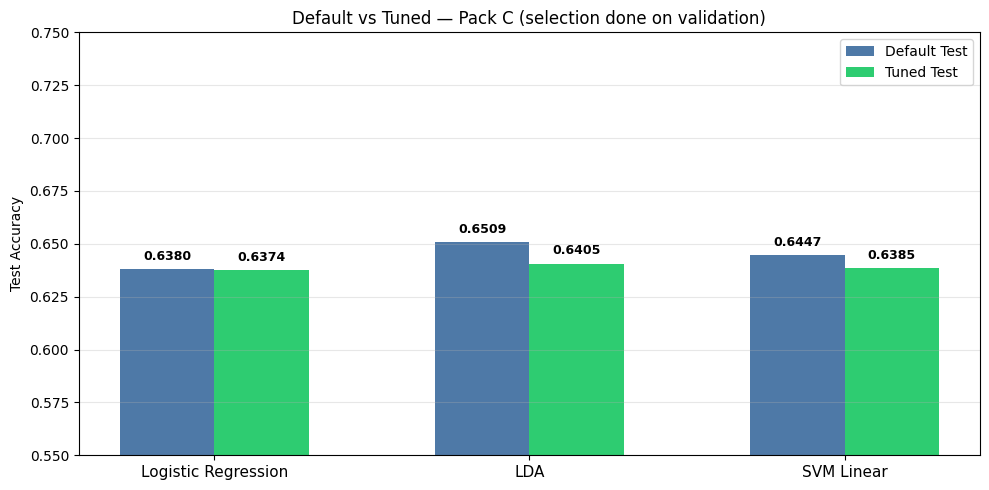

Validation-selected results on Pack C:
  Logistic Regression: val=0.6264, test=0.6374, default test=0.6380
  LDA:                 val=0.6378, test=0.6405, default test=0.6509
  SVM Linear:          val=0.6264, test=0.6385, default test=0.6447


In [26]:
print("===== Hyperparameter Tuning on Pack C (Team + Venue) =====")
print("Selection is based on VALIDATION accuracy. Test is used only once at the end.")
print()

X_train_c, X_val_c, X_test_c, y_train_c, y_val_c, y_test_c = time_based_train_val_test_split(df, PACK_C)

# ── Logistic Regression ──────────────────────────────────────
print("--- Tuning Logistic Regression ---")
best_val_acc = -1
best_C = None
best_logreg_c = None

for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    model = LogisticRegressionModel(C=C)
    model.fit(X_train_c, y_train_c)

    val_pred = model.predict(X_val_c)
    val_acc = accuracy_score(y_val_c, val_pred)
    print(f"  C={C:<8} Validation Accuracy = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_C = C
        best_logreg_c = model

logreg_best_val_c = best_val_acc
logreg_best_acc_c = accuracy_score(y_test_c, best_logreg_c.predict(X_test_c))
print(f"\n  Best C: {best_C}  Validation Accuracy: {logreg_best_val_c:.4f}  Test Accuracy: {logreg_best_acc_c:.4f}")


# ── LDA ──────────────────────────────────────────────────────
print()
print("--- Tuning LDA ---")
best_val_acc = -1
best_solver = None
best_shrinkage = None
best_lda_c = None

lda_configs = [
    {"solver": "svd",  "shrinkage": None},
    {"solver": "lsqr", "shrinkage": "auto"},
    {"solver": "lsqr", "shrinkage": 0.1},
    {"solver": "lsqr", "shrinkage": 0.3},
    {"solver": "lsqr", "shrinkage": 0.5},
    {"solver": "lsqr", "shrinkage": 0.7},
    {"solver": "lsqr", "shrinkage": 0.9},
]

for cfg in lda_configs:
    model = LDAModel(solver=cfg["solver"], shrinkage=cfg["shrinkage"])
    model.fit(X_train_c, y_train_c)

    val_pred = model.predict(X_val_c)
    val_acc = accuracy_score(y_val_c, val_pred)
    print(f"  solver={cfg['solver']:<4} shrinkage={str(cfg['shrinkage']):<6} Validation Accuracy = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_solver = cfg["solver"]
        best_shrinkage = cfg["shrinkage"]
        best_lda_c = model

lda_best_val_c = best_val_acc
lda_best_acc_c = accuracy_score(y_test_c, best_lda_c.predict(X_test_c))
print(f"\n  Best solver: {best_solver}  Best shrinkage: {best_shrinkage}  Validation Accuracy: {lda_best_val_c:.4f}  Test Accuracy: {lda_best_acc_c:.4f}")


# ── Linear SVM ───────────────────────────────────────────────
print()
print("--- Tuning Linear SVM ---")
best_val_acc = -1
best_C = None
best_svm_c = None

for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    model = SVMLinearModel(C=C)
    model.fit(X_train_c, y_train_c)

    val_pred = model.predict(X_val_c)
    val_acc = accuracy_score(y_val_c, val_pred)
    print(f"  C={C:<8} Validation Accuracy = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_C = C
        best_svm_c = model

svm_best_val_c = best_val_acc
svm_best_acc_c = accuracy_score(y_test_c, best_svm_c.predict(X_test_c))
print(f"\n  Best C: {best_C}  Validation Accuracy: {svm_best_val_c:.4f}  Test Accuracy: {svm_best_acc_c:.4f}")


# ── Comparison plot ───────────────────────────────────────────
default_logreg_c = logreg_results["Pack C — Team + Venue"]["accuracy"]
default_lda_c    = lda_results["Pack C — Team + Venue"]["accuracy"]
default_svm_c    = svm_linear_results["Pack C — Team + Venue"]["accuracy"]

fig, ax = plt.subplots(figsize=(10, 5))

models   = ["Logistic Regression", "LDA", "SVM Linear"]
defaults = [default_logreg_c, default_lda_c, default_svm_c]
tuned    = [logreg_best_acc_c, lda_best_acc_c, svm_best_acc_c]

x = np.arange(len(models))
width = 0.3

bars1 = ax.bar(x - width/2, defaults, width, label="Default Test", color="#4e79a7")
bars2 = ax.bar(x + width/2, tuned,    width, label="Tuned Test",   color="#2ecc71")

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f"{bar.get_height():.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0.55, 0.75)
ax.set_ylabel("Test Accuracy")
ax.set_title("Default vs Tuned — Pack C (selection done on validation)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Validation-selected results on Pack C:")
print(f"  Logistic Regression: val={logreg_best_val_c:.4f}, test={logreg_best_acc_c:.4f}, default test={default_logreg_c:.4f}")
print(f"  LDA:                 val={lda_best_val_c:.4f}, test={lda_best_acc_c:.4f}, default test={default_lda_c:.4f}")
print(f"  SVM Linear:          val={svm_best_val_c:.4f}, test={svm_best_acc_c:.4f}, default test={default_svm_c:.4f}")

---
### Using Grid Search to find the best parameters for each model on Pack D (Compact Combined)

===== Hyperparameter Tuning on Pack D (Compact Combined) =====
Selection is based on VALIDATION accuracy. Test is used only once at the end.

--- Tuning Logistic Regression ---
  C=0.01     Validation Accuracy = 0.6171
  C=0.1      Validation Accuracy = 0.6161
  C=1.0      Validation Accuracy = 0.6109
  C=10.0     Validation Accuracy = 0.6109
  C=100.0    Validation Accuracy = 0.6120

  Best C: 0.01  Validation Accuracy: 0.6171  Test Accuracy: 0.6364

--- Tuning LDA ---
[LDA] Training done.
  solver=svd  shrinkage=None   Validation Accuracy = 0.6161
[LDA] Training done.
  solver=lsqr shrinkage=auto   Validation Accuracy = 0.6192
[LDA] Training done.
  solver=lsqr shrinkage=0.1    Validation Accuracy = 0.6182
[LDA] Training done.
  solver=lsqr shrinkage=0.3    Validation Accuracy = 0.6161
[LDA] Training done.
  solver=lsqr shrinkage=0.5    Validation Accuracy = 0.6244
[LDA] Training done.
  solver=lsqr shrinkage=0.7    Validation Accuracy = 0.6223
[LDA] Training done.
  solver=lsqr shri

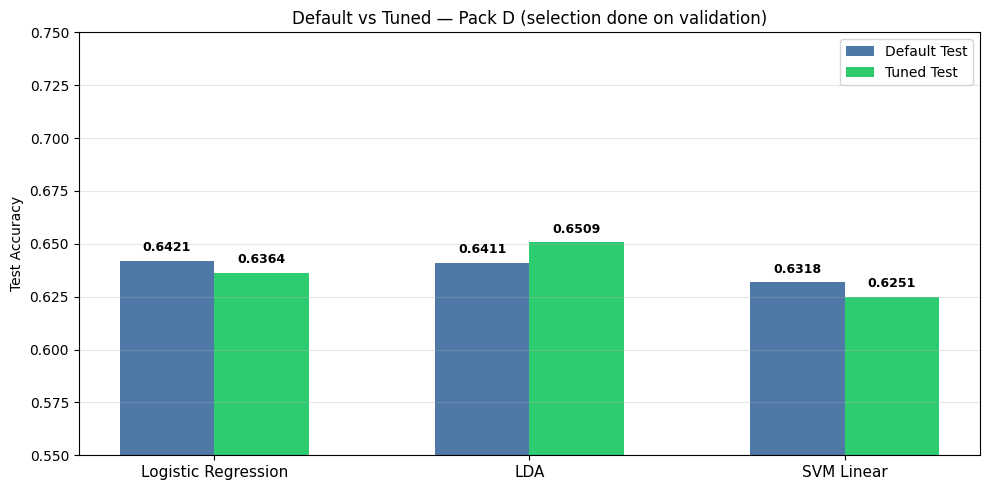

Validation-selected results on Pack D:
  Logistic Regression: val=0.6171, test=0.6364, default test=0.6421
  LDA:                 val=0.6254, test=0.6509, default test=0.6411
  SVM Linear:          val=0.6120, test=0.6251, default test=0.6318


In [27]:
print("===== Hyperparameter Tuning on Pack D (Compact Combined) =====")
print("Selection is based on VALIDATION accuracy. Test is used only once at the end.")
print()

X_train_d, X_val_d, X_test_d, y_train_d, y_val_d, y_test_d = time_based_train_val_test_split(df, PACK_D)

# ── Logistic Regression ──────────────────────────────────────
print("--- Tuning Logistic Regression ---")
best_val_acc = -1
best_C = None
best_logreg_d = None

for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    model = LogisticRegressionModel(C=C)
    model.fit(X_train_d, y_train_d)

    val_pred = model.predict(X_val_d)
    val_acc = accuracy_score(y_val_d, val_pred)
    print(f"  C={C:<8} Validation Accuracy = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_C = C
        best_logreg_d = model

logreg_best_val_d = best_val_acc
logreg_best_acc_d = accuracy_score(y_test_d, best_logreg_d.predict(X_test_d))
print(f"\n  Best C: {best_C}  Validation Accuracy: {logreg_best_val_d:.4f}  Test Accuracy: {logreg_best_acc_d:.4f}")


# ── LDA ──────────────────────────────────────────────────────
print()
print("--- Tuning LDA ---")
best_val_acc = -1
best_solver = None
best_shrinkage = None
best_lda_d = None

lda_configs = [
    {"solver": "svd",  "shrinkage": None},
    {"solver": "lsqr", "shrinkage": "auto"},
    {"solver": "lsqr", "shrinkage": 0.1},
    {"solver": "lsqr", "shrinkage": 0.3},
    {"solver": "lsqr", "shrinkage": 0.5},
    {"solver": "lsqr", "shrinkage": 0.7},
    {"solver": "lsqr", "shrinkage": 0.9},
]

for cfg in lda_configs:
    model = LDAModel(solver=cfg["solver"], shrinkage=cfg["shrinkage"])
    model.fit(X_train_d, y_train_d)

    val_pred = model.predict(X_val_d)
    val_acc = accuracy_score(y_val_d, val_pred)
    print(f"  solver={cfg['solver']:<4} shrinkage={str(cfg['shrinkage']):<6} Validation Accuracy = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_solver = cfg["solver"]
        best_shrinkage = cfg["shrinkage"]
        best_lda_d = model

lda_best_val_d = best_val_acc
lda_best_acc_d = accuracy_score(y_test_d, best_lda_d.predict(X_test_d))
print(f"\n  Best solver: {best_solver}  Best shrinkage: {best_shrinkage}  Validation Accuracy: {lda_best_val_d:.4f}  Test Accuracy: {lda_best_acc_d:.4f}")


# ── Linear SVM ───────────────────────────────────────────────
print()
print("--- Tuning Linear SVM ---")
best_val_acc = -1
best_C = None
best_svm_d = None

for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    model = SVMLinearModel(C=C)
    model.fit(X_train_d, y_train_d)

    val_pred = model.predict(X_val_d)
    val_acc = accuracy_score(y_val_d, val_pred)
    print(f"  C={C:<8} Validation Accuracy = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_C = C
        best_svm_d = model

svm_best_val_d = best_val_acc
svm_best_acc_d = accuracy_score(y_test_d, best_svm_d.predict(X_test_d))
print(f"\n  Best C: {best_C}  Validation Accuracy: {svm_best_val_d:.4f}  Test Accuracy: {svm_best_acc_d:.4f}")


# ── Comparison plot ───────────────────────────────────────────
default_logreg_d = logreg_results["Pack D — Compact Combined"]["accuracy"]
default_lda_d    = lda_results["Pack D — Compact Combined"]["accuracy"]
default_svm_d    = svm_linear_results["Pack D — Compact Combined"]["accuracy"]

fig, ax = plt.subplots(figsize=(10, 5))

models   = ["Logistic Regression", "LDA", "SVM Linear"]
defaults = [default_logreg_d, default_lda_d, default_svm_d]
tuned    = [logreg_best_acc_d, lda_best_acc_d, svm_best_acc_d]

x = np.arange(len(models))
width = 0.3

bars1 = ax.bar(x - width/2, defaults, width, label="Default Test", color="#4e79a7")
bars2 = ax.bar(x + width/2, tuned,    width, label="Tuned Test",   color="#2ecc71")

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f"{bar.get_height():.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0.55, 0.75)
ax.set_ylabel("Test Accuracy")
ax.set_title("Default vs Tuned — Pack D (selection done on validation)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Validation-selected results on Pack D:")
print(f"  Logistic Regression: val={logreg_best_val_d:.4f}, test={logreg_best_acc_d:.4f}, default test={default_logreg_d:.4f}")
print(f"  LDA:                 val={lda_best_val_d:.4f}, test={lda_best_acc_d:.4f}, default test={default_lda_d:.4f}")
print(f"  SVM Linear:          val={svm_best_val_d:.4f}, test={svm_best_acc_d:.4f}, default test={default_svm_d:.4f}")

## Custom handpicked feature set ##

Pack G feature count: 42
All Pack G columns found.

[LDA] Training done.
[SVM Linear] Training done.
===== Pack G Results =====
Logistic Regression: Accuracy = 0.6400, Precision = 0.6379, Recall = 0.5733, F1 = 0.6039
LDA:                 Accuracy = 0.6405, Precision = 0.6421, Recall = 0.5625, F1 = 0.5997
SVM Linear:          Accuracy = 0.6318, Precision = 0.6299, Recall = 0.5593, F1 = 0.5925


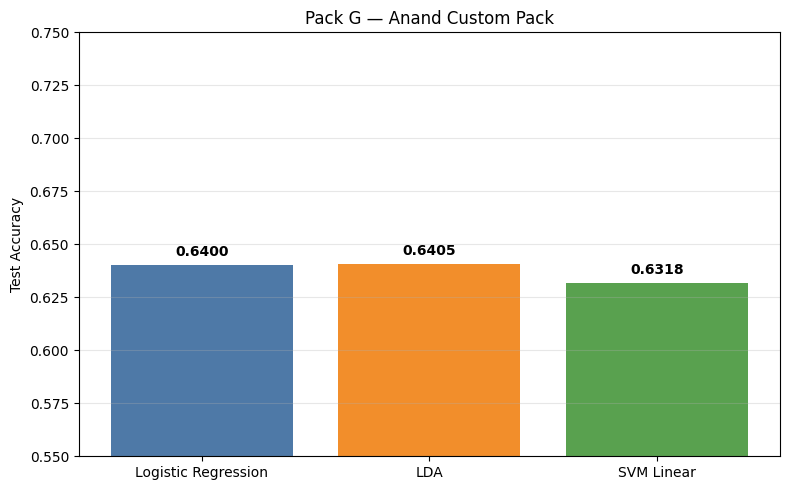

In [29]:
# ===== Pack G — Anand Custom Pack =====

PACK_G = [
    "diff_prior_matches",
    "diff_prior_win_pct",
    "diff_prior_avg_runs_scored",
    "diff_prior_avg_runs_conceded",
    "diff_last5_win_pct",
    "diff_last5_avg_runs_scored",
    "diff_last5_avg_runs_conceded",

    "team1_won_toss_and_batted",
    "team1_won_toss_and_fielded",
    "team2_won_toss_and_batted",
    "team2_won_toss_and_fielded",

    "diff_allrounder_count",

    "diff_top_order_avg_batting_avg",
    "diff_top_order_avg_strike_rate",

    "diff_middle_order_avg_batting_avg",
    "diff_middle_order_avg_strike_rate",
 
    "diff_lower_order_avg_batting_avg",
    "diff_lower_order_avg_strike_rate",

    "diff_bowlers_pp_bowling_avg",
    "diff_bowlers_pp_bowling_strike_rate",
    "diff_bowlers_pp_bowling_economy",
    "diff_bowlers_mid_bowling_avg",
    "diff_bowlers_mid_bowling_strike_rate",
    "diff_bowlers_mid_bowling_economy",
    "diff_bowlers_death_bowling_avg",
    "diff_bowlers_death_bowling_strike_rate",
    "diff_bowlers_death_bowling_economy",

    "venue_prior_matches",
    "venue_prior_avg_first_innings_runs",
    "venue_prior_avg_second_innings_runs",
    "venue_prior_chasing_win_pct",
    "venue_prior_defending_win_pct",

    "diff_prior_matches_at_venue",
    "diff_prior_win_pct_at_venue",
    "diff_prior_avg_runs_scored_at_venue",
    "diff_prior_avg_runs_conceded_at_venue",
    "diff_xi_players_with_venue_history",
    "diff_xi_avg_venue_experience",
    "diff_xi_avg_venue_batting_avg",
    "diff_xi_avg_venue_strike_rate",
    "diff_xi_avg_venue_bowling_avg",
    "diff_xi_avg_venue_bowling_economy",
]

print(f"Pack G feature count: {len(PACK_G)}")

missing_cols = [c for c in PACK_G if c not in df.columns]
if missing_cols:
    print("Missing columns:")
    for c in missing_cols:
        print(" -", c)
else:
    print("All Pack G columns found.\n")

    X_train_g, X_test_g, y_train_g, y_test_g = time_based_split(df, PACK_G)

    # Logistic Regression
    logreg_g = LogisticRegressionModel()
    logreg_g.fit(X_train_g, y_train_g)
    logreg_g_pred = logreg_g.predict(X_test_g)
    logreg_g_results = get_metrics(y_test_g, logreg_g_pred)

    # LDA
    lda_g = LDAModel()
    lda_g.fit(X_train_g, y_train_g)
    lda_g_pred = lda_g.predict(X_test_g)
    lda_g_results = get_metrics(y_test_g, lda_g_pred)

    # Linear SVM
    svm_g = SVMLinearModel()
    svm_g.fit(X_train_g, y_train_g)
    svm_g_pred = svm_g.predict(X_test_g)
    svm_g_results = get_metrics(y_test_g, svm_g_pred)

    print("===== Pack G Results =====")
    print(f"Logistic Regression: Accuracy = {logreg_g_results['accuracy']:.4f}, "
          f"Precision = {logreg_g_results['precision']:.4f}, "
          f"Recall = {logreg_g_results['recall']:.4f}, "
          f"F1 = {logreg_g_results['f1']:.4f}")

    print(f"LDA:                 Accuracy = {lda_g_results['accuracy']:.4f}, "
          f"Precision = {lda_g_results['precision']:.4f}, "
          f"Recall = {lda_g_results['recall']:.4f}, "
          f"F1 = {lda_g_results['f1']:.4f}")

    print(f"SVM Linear:          Accuracy = {svm_g_results['accuracy']:.4f}, "
          f"Precision = {svm_g_results['precision']:.4f}, "
          f"Recall = {svm_g_results['recall']:.4f}, "
          f"F1 = {svm_g_results['f1']:.4f}")

    # Optional quick comparison plot
    models = ["Logistic Regression", "LDA", "SVM Linear"]
    accuracies = [
        logreg_g_results["accuracy"],
        lda_g_results["accuracy"],
        svm_g_results["accuracy"],
    ]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(models, accuracies, color=["#4e79a7", "#f28e2b", "#59a14f"])
    plt.ylim(0.55, 0.75)
    plt.ylabel("Test Accuracy")
    plt.title("Pack G — Anand Custom Pack")

    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{bar.get_height():.4f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

## COMPARE DIFFERENT TRAINING TABLES ##


===== Team V1 =====
shape: (9691, 61)
feature count: 43
[LDA] Training done.
[SVM Linear] Training done.

===== Player V2 =====
shape: (9691, 200)
feature count: 184
[LDA] Training done.
[SVM Linear] Training done.

===== V1 Full =====
shape: (9691, 90)
feature count: 72
[LDA] Training done.
[SVM Linear] Training done.

===== V2 Full =====
shape: (9691, 283)
feature count: 265
[LDA] Training done.
[SVM Linear] Training done.

===== V3 Team+Venue =====
shape: (9691, 99)
feature count: 81
[LDA] Training done.
[SVM Linear] Training done.


,table,model,feature_count,accuracy,precision,recall,f1
0,V1 Full,LDA,72,0.658587,0.644880,0.637931,0.641387
1,V3 Team+Venue,LDA,81,0.644662,0.641420,0.584052,0.611393
2,Team V1,LDA,43,0.640536,0.628763,0.607759,0.618082
3,V2 Full,LDA,265,0.634863,0.620614,0.609914,0.615217
4,Player V2,LDA,184,0.614234,0.593946,0.613147,0.603393
5,V1 Full,Logistic Regression,72,0.658587,0.643011,0.644397,0.643703
6,Team V1,Logistic Regression,43,0.636926,0.621475,0.617457,0.619459
7,V2 Full,Logistic Regression,265,0.635379,0.621830,0.607759,0.614714
8,V3 Team+Venue,Logistic Regression,81,0.635379,0.627746,0.585129,0.605689
9,Player V2,Logistic Regression,184,0.615266,0.595188,0.613147,0.604034


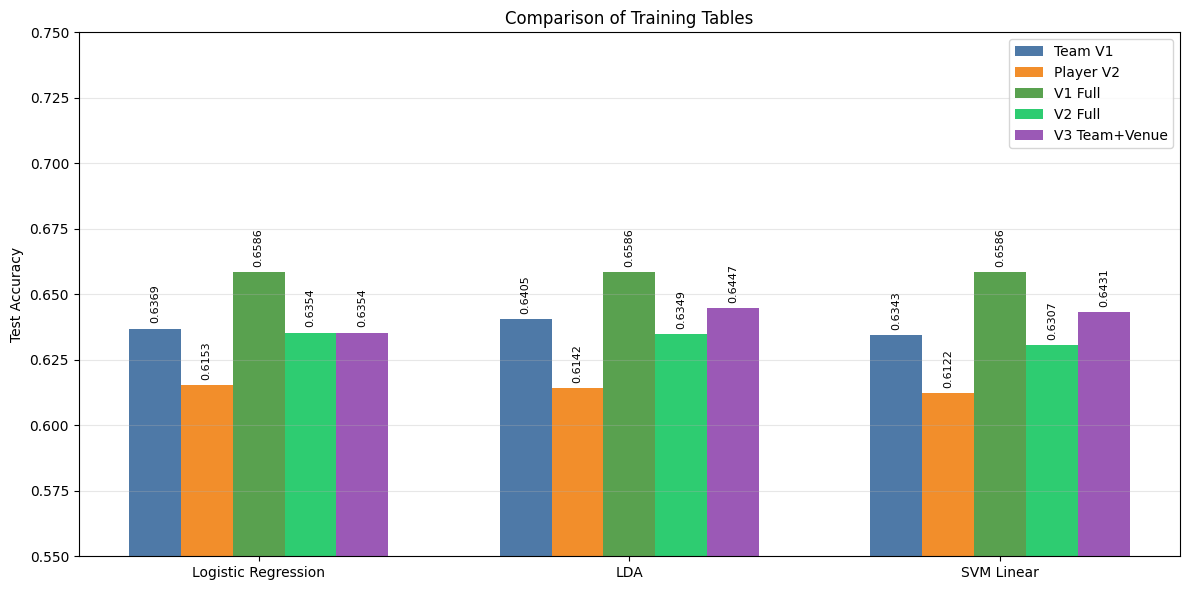

In [34]:
# ===== Compare Multiple Training Tables (Parquet) =====

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TABLE_PATHS = {
    "Team V1": PROJECT_ROOT / "data" / "processed" / "training_table_team_v1.parquet",
    "Player V2": PROJECT_ROOT / "data" / "processed" / "training_table_player_v2.parquet",
    "V1 Full": PROJECT_ROOT / "data" / "processed" / "training_table_v1.parquet",
    "V2 Full": PROJECT_ROOT / "data" / "processed" / "training_table_v2.parquet",
    "V3 Team+Venue": PROJECT_ROOT / "data" / "processed" / "training_table_v3.parquet",
}

# Non-feature columns
EXCLUDE_COLS_COMPARE = {
    "match_id",
    "date_start",
    "team1",
    "team2",
    "venue",
    "city",
    "winner",
    "label_team1_win",
    "source_bucket",
    "official_status",
    "competition_folder",
    "event_name",
    "match_type",
    "gender",
    "toss_winner",
    "toss_decision",
    "has_winner",
    "is_binary_outcome",
}

all_results = []

for table_name, path in TABLE_PATHS.items():
    print(f"\n===== {table_name} =====")
    df_table = pd.read_parquet(path)

    # Filter label rows
    df_table = df_table[df_table["label_team1_win"].notna()].copy()
    if "is_binary_outcome" in df_table.columns:
        df_table = df_table[df_table["is_binary_outcome"] == True].copy()
    
    df_table["label_team1_win"] = df_table["label_team1_win"].astype(int)
    
    print("shape:", df_table.shape)
    
    feature_cols = [c for c in df_table.columns if c not in EXCLUDE_COLS_COMPARE]
    print("feature count:", len(feature_cols))
    
    X_train, X_test, y_train, y_test = time_based_split(df_table, feature_cols)

    # Logistic Regression
    logreg = LogisticRegressionModel()
    logreg.fit(X_train, y_train)
    res = get_metrics(y_test, logreg.predict(X_test))
    all_results.append({"table": table_name, "model": "Logistic Regression", "feature_count": len(feature_cols), **res})

    # LDA
    lda = LDAModel()
    lda.fit(X_train, y_train)
    res = get_metrics(y_test, lda.predict(X_test))
    all_results.append({"table": table_name, "model": "LDA", "feature_count": len(feature_cols), **res})

    # Linear SVM
    svm = SVMLinearModel()
    svm.fit(X_train, y_train)
    res = get_metrics(y_test, svm.predict(X_test))
    all_results.append({"table": table_name, "model": "SVM Linear", "feature_count": len(feature_cols), **res})

results_compare_df = pd.DataFrame(all_results)

display(
    results_compare_df[
        ["table", "model", "feature_count", "accuracy", "precision", "recall", "f1"]
    ].sort_values(["model", "accuracy"], ascending=[True, False]).reset_index(drop=True)
)

# ===== Accuracy comparison plot =====
fig, ax = plt.subplots(figsize=(12, 6))

models = ["Logistic Regression", "LDA", "SVM Linear"]
table_names = list(TABLE_PATHS.keys())
x = np.arange(len(models))
width = 0.14

colors = ["#4e79a7", "#f28e2b", "#59a14f", "#2ecc71", "#9b59b6"]

for i, table_name in enumerate(table_names):
    accs = [
        results_compare_df[
            (results_compare_df["table"] == table_name) &
            (results_compare_df["model"] == model)
        ]["accuracy"].iloc[0]
        for model in models
    ]
    bars = ax.bar(x + (i - (len(table_names)-1)/2) * width, accs, width, label=table_name, color=colors[i % len(colors)])
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.4f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.55, 0.75)
ax.set_ylabel("Test Accuracy")
ax.set_title("Comparison of Training Tables")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
logreg_pred_v1 = logreg_v1.predict(X_test_v1)
lda_pred_v1 = lda_v1.predict(X_test_v1)
svm_pred_v1 = svm_v1.predict(X_test_v1)

print("LogReg vs LDA same predictions:", (logreg_pred_v1 == lda_pred_v1).mean())
print("LogReg vs SVM same predictions:", (logreg_pred_v1 == svm_pred_v1).mean())
print("LDA vs SVM same predictions:", (lda_pred_v1 == svm_pred_v1).mean())

LogReg vs LDA same predictions: 0.9711191335740073
LogReg vs SVM same predictions: 0.9535843218153688
LDA vs SVM same predictions: 0.9556472408457968
